In [1]:
# ============================================
# Week 4: Feature Importance & Ablation Study
# Student: Aylin Bozkurt & Jana Mumm
# Dataset: [winequality-white.csv]
# ============================================

In [2]:
# Installiere imbalanced-learn (falls nicht vorhanden)
%pip install imbalanced-learn

# IMPORTS FOR HANDLING IMBALANCED DATASETS
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek  # Kombiniert SMOTE + Tomek Links
from collections import Counter

# -------- IMPORTS --------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

%pip install ucimlrepo
import ucimlrepo

from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier # or your chosen model
from sklearn.feature_selection import (
mutual_info_classif,
RFE,
SelectKBest,
f_classif
)
from sklearn.metrics import *
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully.")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully.


In [3]:
# ============================================================
# SETUP: CREATE FOLDER STRUCTURE AUTOMATICALLY
# ============================================================
import os

# Create folders
folders_to_create = [
    'data',
    'plots/01_exploratory',
    'plots/02_baseline',
    'plots/03_feature_importance',
    'plots/04_ablation_study',
    'plots/05_statistical_analysis',
    'results'
]

for folder in folders_to_create:
    os.makedirs(folder, exist_ok=True)
print("Folder structure created successfully.")


Folder structure created successfully.


In [4]:
# Set random seed and configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TEST_SIZE = 0.2
CV_FOLDS = 5
MODEL_PARAMS = {
    'n_estimators': 100,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'random_state': RANDOM_STATE,
    'n_jobs': -1
}

# ============================================================
# SECTION 1: LOAD DATA USING UCI ML REPOSITORY
# ============================================================

print("="*70)
print("1. LOAD DATA - UCI ML REPOSITORY (WHITE WINE ONLY)")
print("="*70)

# ============================================================
# 1.1 INSTALL UCIMLREPO (if needed)
# ============================================================
print("\nStep 1.1: Ensuring ucimlrepo is installed...")

try:
    from ucimlrepo import fetch_ucirepo
    print("✓ ucimlrepo already installed")
except ImportError:
    print("⚠ ucimlrepo not found, installing...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo"])
    from ucimlrepo import fetch_ucirepo
    print("✓ ucimlrepo installed successfully")

# ============================================================
# 1.2 FETCH DATASET FROM UCI
# ============================================================
print("\nStep 1.2: Fetching wine quality dataset from UCI...")

# Fetch dataset (ID=186 = Wine Quality)
wine_quality = fetch_ucirepo(id=186)

print("✓ Dataset fetched successfully!")
print("   (Contains both red and white wine - will filter for white only)")

# ============================================================
# 1.3 DISPLAY METADATA
# ============================================================
print("\nStep 1.3: Dataset Metadata")
print("-"*70)

# Metadata
print("\nDataset Information:")
print(f"  Name: {wine_quality.metadata['name']}")
print(f"  Dataset ID: 186")
print(f"  Repository: UCI Machine Learning Repository")

# Show full metadata
print("\nFull Metadata:")
print(wine_quality.metadata)

# ============================================================
# 1.4 DISPLAY VARIABLE INFORMATION
# ============================================================
print("\nStep 1.4: Variable Information")
print("-"*70)

print("\nVariable Details:")
print(wine_quality.variables)

# ============================================================
# 1.5 EXTRACT DATA (FEATURES & TARGET) - WHITE WINE ONLY! 
# ============================================================
print("\nStep 1.5: Extracting features and target (WHITE WINE ONLY)...")

# WICHTIG: Zuerst DEFINIEREN wir X_full und y_full
X_full = wine_quality.data.features  # All physicochemical features (red + white)
y_full = wine_quality.data.targets   # Quality score (red + white)

print(f"\n📊 Original dataset (red + white combined):")
print(f"  Shape: {X_full.shape}")
print(f"  Total samples: {len(X_full):,}")

# ============================================================
# FILTER FOR WHITE WINE ONLY
# ============================================================
print(f"\n🍷 Filtering for WHITE WINE only...")

# The UCI Wine Quality dataset (ID=186) contains both red and white wine
# Structure: First 1599 rows = RED wine, Next 4898 rows = WHITE wine
# Total: 1599 + 4898 = 6497 rows

# Check if this is the combined dataset
if len(X_full) == 6497:
    print(f"   ✓ Combined dataset detected (6497 samples)")
    print(f"   → Red wine:   Rows 0-1598   (1,599 samples)")
    print(f"   → White wine: Rows 1599-6496 (4,898 samples)")
    
    # Extract ONLY white wine (rows 1599 onwards)
    X = X_full.iloc[1599:].copy()  # White wine features
    y = y_full.iloc[1599:].copy()  # White wine quality
    
    # Reset index to start from 0
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
    
    print(f"\n✅ WHITE WINE extracted successfully!")
    print(f"   Shape: {X.shape}")
    print(f"   Samples: {len(X):,}")
    
elif len(X_full) == 4898:
    print(f"   ✓ Already white wine dataset ({len(X_full)} samples)")
    X = X_full.copy()
    y = y_full.copy()
    
else:
    print(f"   ⚠️  WARNING: Unexpected dataset size: {len(X_full)}")
    print(f"   → Assuming this is the complete dataset")
    X = X_full.copy()
    y = y_full.copy()

print(f"\n✓ Features extracted (WHITE WINE):")
print(f"  Shape: {X.shape}")
print(f"  Columns: {X.columns.tolist()}")

print(f"\n✓ Target extracted (WHITE WINE):")
print(f"  Shape: {y.shape}")
print(f"  Column: {y.columns.tolist()}")


# ============================================================
# 1.6 COMBINE FEATURES AND TARGET
# ============================================================
print("\nStep 1.6: Combining features and target...")

# Combine into single DataFrame
df = pd.concat([X, y], axis=1)

print(f"✓ Combined dataset (white wine only):")
print(f"  Total samples: {len(df):,}")
print(f"  Total columns: {len(df.columns)}")
print(f"  Wine type:     WHITE WINE")

# ============================================================
# 1.7 CHECK DATA TYPES (before conversion)
# ============================================================
print("\nStep 1.7: Checking data types...")
print("-"*70)

print(f"\nData types (raw from UCI):")
print(df.dtypes)

# Count string columns
string_columns = df.select_dtypes(include=['object']).columns
if len(string_columns) > 0:
    print(f"\n⚠ Found {len(string_columns)} string columns:")
    print(f"  {list(string_columns)}")
    print(f"  → Will convert to numeric...")
else:
    print(f"\n✓ All columns already numeric!")

# ============================================================
# 1.8 CONVERT STRINGS TO FLOAT (if needed)
# ============================================================
print("\nStep 1.8: Converting to numeric types...")

original_length = len(df)

# Convert each column to numeric
for col in df.columns:
    if df[col].dtype == 'object':  # Only convert string columns
        print(f"  Converting: {col}")
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Check for NaN values (failed conversions)
nan_counts = df.isnull().sum()
total_nans = nan_counts.sum()

if total_nans > 0:
    print(f"\n⚠ Found {total_nans} NaN values (failed conversions):")
    print(nan_counts[nan_counts > 0])
    
    # Remove rows with NaN
    df = df.dropna()
    print(f"✓ Removed {original_length - len(df)} rows with NaN")
else:
    print(f"\n✓ No NaN values - all conversions successful!")

# ============================================================
# 1.9 VERIFY CONVERSION
# ============================================================
print("\nStep 1.9: Verifying data types after conversion...")

print(f"\nData types AFTER conversion:")
print(df.dtypes)

# Check if all are numeric
all_numeric = all(df[col].dtype in ['float64', 'int64'] for col in df.columns)

if all_numeric:
    print(f"\n✅ SUCCESS: All columns are numeric!")
else:
    print(f"\n⚠ WARNING: Some columns are still not numeric!")

# ============================================================
# 1.10 DATA QUALITY CHECK: DUPLICATE REMOVAL
# ============================================================
print("\nStep 1.10: Data quality check - Duplicate removal...")
print("-"*70)

# Check dataset size before duplicate removal
print(f"\n📊 Dataset before duplicate check:")
print(f"   Total samples: {len(df):,}")
print(f"   Shape: {df.shape}")

# Count duplicate rows
n_duplicates = df.duplicated().sum()
duplicate_percentage = (n_duplicates / len(df)) * 100 if len(df) > 0 else 0

print(f"\n🔍 Checking for duplicate rows...")
print(f"   Duplicate rows found: {n_duplicates}")
print(f"   Percentage: {duplicate_percentage:.2f}%")

# Handle duplicates
if n_duplicates > 0:
    print(f"\n⚠️  WARNING: {n_duplicates} duplicate row(s) detected!")
    
    # Show examples of duplicates
    print(f"\n   First 3 duplicate samples (showing both original and duplicate):")
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
    # duplicated(keep=False) marks ALL duplicates (not just 2nd occurrence)
    # sort_values groups identical rows together for easier viewing
    print(duplicates_df.head(6))  # Show up to 6 rows (3 pairs)
    
    # Remove duplicates (keep first occurrence)
    print(f"\n🧹 Removing duplicate rows...")
    df_before = len(df)
    df = df.drop_duplicates(keep='first')  
    # drop_duplicates(keep='first') keeps the first occurrence, removes rest
    df_after = len(df)
    removed = df_before - df_after
    
    print(f"\n✅ DUPLICATES REMOVED:")
    print(f"   Samples before: {df_before:,}")
    print(f"   Samples after:  {df_after:,}")
    print(f"   Removed:        {removed:,} duplicates ({removed/df_before*100:.2f}%)")
    
else:
    print(f"\n✅ NO DUPLICATES FOUND")
    print(f"   Dataset is clean - all {len(df):,} rows are unique")
    print(f"   No deduplication required")

# Final dataset size
print(f"\n📊 Dataset after duplicate removal:")
print(f"   Final samples: {len(df):,}")
print(f"   Final shape:   {df.shape}")
print(f"   Features:      {len(df.columns) - 1} (excluding target)")

# Reset index after duplicate removal
df = df.reset_index(drop=True)
# reset_index(drop=True) creates new sequential index 0,1,2,... 
# drop=True discards old index (doesn't create new column)
print(f"   Index reset:   ✓ (0 to {len(df)-1})")

# ============================================================
# 1.11 DATASET SUMMARY
# ============================================================
print("\n" + "="*70)
print("DATASET SUMMARY")
print("="*70)

print(f"""
Dataset Information:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Source:           UCI ML Repository (ID: 186)
Dataset:          Wine Quality Dataset
Original samples: {original_length:,}
Final samples:    {len(df):,}
Features:         {len(df.columns) - 1}  (excluding target)
Target variable:  quality

Quality range:    {df['quality'].min()} - {df['quality'].max()}
Quality mean:     {df['quality'].mean():.2f}

Feature columns:
{df.columns.tolist()}

All columns are numeric: {'✓ YES' if all_numeric else '✗ NO'}
Duplicates removed:      {n_duplicates if n_duplicates > 0 else 'None (0)'}
""")

# Show sample data
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nBasic statistics:")
print(df.describe())

# ============================================================
# 1.12 TEST CORRELATION MATRIX
# ============================================================
print("\nStep 1.12: Testing correlation matrix...")

try:
    correlation_matrix = df.corr()
    print(f"✅ Correlation matrix computed successfully!")
    print(f"   Shape: {correlation_matrix.shape}")
    
    # Show correlations with quality
    print(f"\nTop 5 features correlated with quality:")
    quality_corr = correlation_matrix['quality'].sort_values(ascending=False)
    print(quality_corr.head(6))  # Top 6 (including quality itself)
    
except Exception as e:
    print(f"❌ Correlation matrix failed: {e}")

# ============================================================
# 1.13 SAVE CLEANED DATASET (OPTIONAL)
# ============================================================
print("\nStep 1.13: Saving cleaned dataset...")

df.to_csv('data/winequality-cleaned.csv', sep=';', index=False)
print(f"✓ Cleaned dataset saved to: data/winequality-cleaned.csv")

print("\n" + "="*70)
print("DATA LOADING COMPLETE ✓")
print("="*70)

print(f"""
✅ Ready to continue with analysis!

Next steps:
  • Section 2: Exploratory Data Analysis
  • Section 3: Preprocessing
  • Section 4: Baseline Model
  • Section 5: Feature Selection
  • Section 6: Ablation Study
  • Section 7: Visualizations
  • Section 8: Statistical Analysis
  • Section 9: Results Export
""")


1. LOAD DATA - UCI ML REPOSITORY (WHITE WINE ONLY)

Step 1.1: Ensuring ucimlrepo is installed...
✓ ucimlrepo already installed

Step 1.2: Fetching wine quality dataset from UCI...
✓ Dataset fetched successfully!
   (Contains both red and white wine - will filter for white only)

Step 1.3: Dataset Metadata
----------------------------------------------------------------------

Dataset Information:
  Name: Wine Quality
  Dataset ID: 186
  Repository: UCI Machine Learning Repository

Full Metadata:
{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression

In [5]:
# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# -------- CONFIGURATION --------
TEST_SIZE = 0.2
CV_FOLDS = 5
MODEL_PARAMS = {
# Your model parameters
'random_state': RANDOM_STATE
}
# -------- 1. LOAD DATA --------
print("\n" + "="*60)
print("1. LOAD DATA")
print("="*60)

  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
  
# metadata 
print(wine_quality.metadata) 
  
# variable information 
print(wine_quality.variables) 



1. LOAD DATA
{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wi

In [6]:
print("\n" + "-"*60) 
print("2.2 CORRELATION ANALYSIS")
print("-"*60)
# Géron Chapter 2: "Chapter 2. End-to-End Machine Learning Project" - Looking for Correlations
# standard correlation coefficient (also called Pearson's r)



------------------------------------------------------------
2.2 CORRELATION ANALYSIS
------------------------------------------------------------



1. Correlation with Target (Quality):
quality                 1.000000
alcohol                 0.462869
pH                      0.123829
sulphates               0.053200
free_sulfur_dioxide     0.010507
citric_acid             0.007065
residual_sugar         -0.117339
fixed_acidity          -0.124636
total_sulfur_dioxide   -0.183356
volatile_acidity       -0.190678
chlorides              -0.217739
density                -0.337805
Name: quality, dtype: float64

2. Top 5 Features Most Correlated with Quality:
   - alcohol: 0.4629
   - pH: 0.1238
   - sulphates: 0.0532
   - free_sulfur_dioxide: 0.0105
   - citric_acid: 0.0071

3. Bottom 5 Features Least Correlated with Quality:
   - fixed_acidity: -0.1246
   - total_sulfur_dioxide: -0.1834
   - volatile_acidity: -0.1907
   - chlorides: -0.2177
   - density: -0.3378

------------------------------------------------------------
Creating FIGURE 1: Correlation Matrix Heatmap
------------------------------------------------------------
✓ Figu

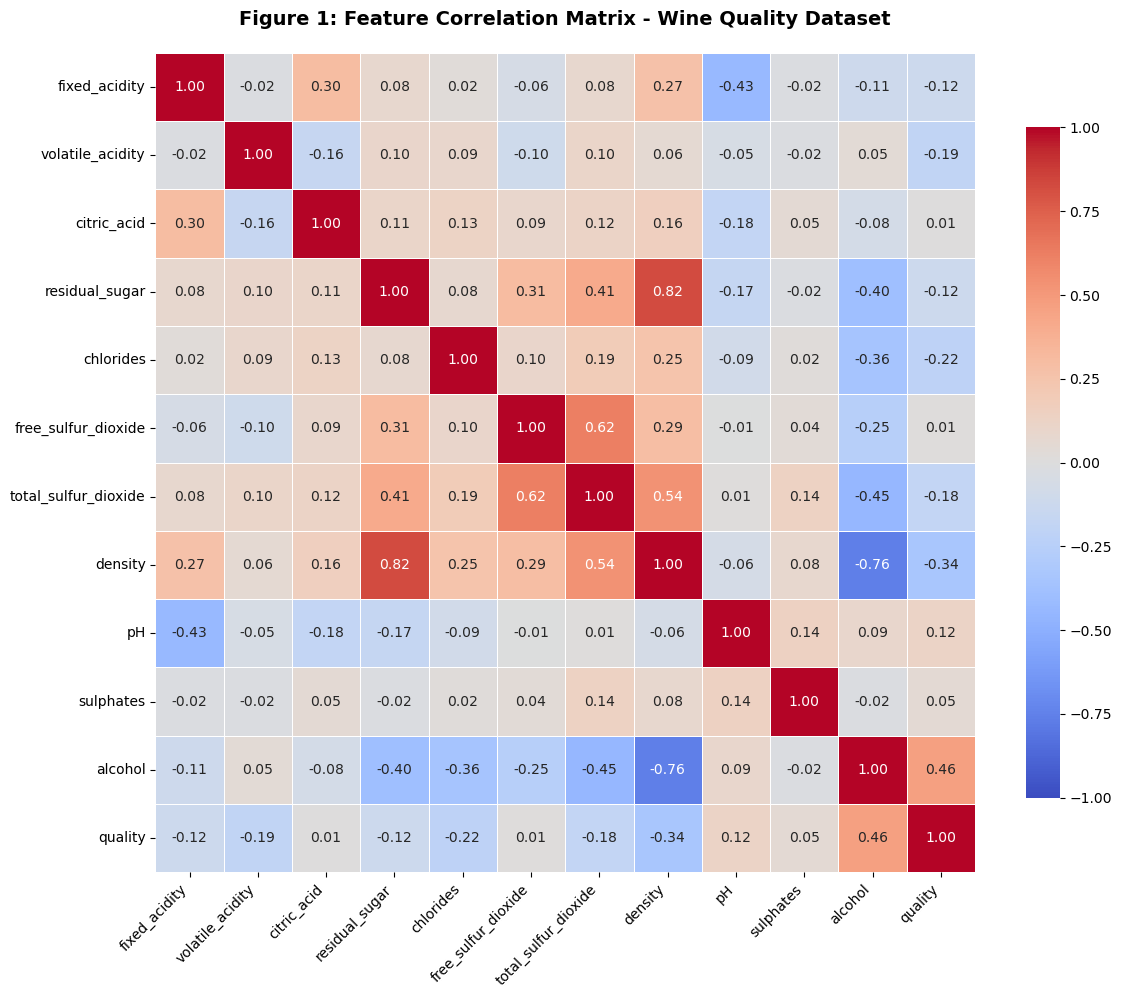


------------------------------------------------------------
Creating Additional Visualization: Feature-Target Correlation
------------------------------------------------------------
✓ Additional visualization saved as 'feature_target_correlation.png'
  Green bars = positive correlation with quality
  Red bars = negative correlation with quality


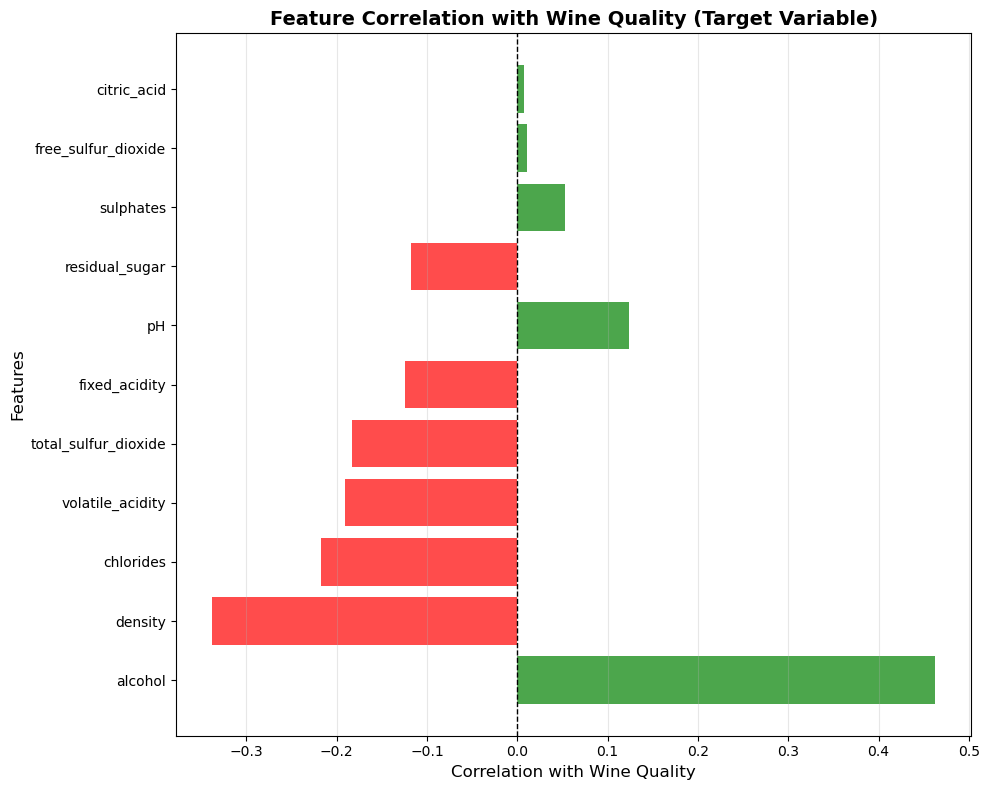


------------------------------------------------------------
Creating Scatter Matrix (Géron Method)
------------------------------------------------------------
Selected attributes for scatter matrix: ['quality', 'alcohol', 'pH', 'sulphates']
✓ Scatter matrix saved as 'scatter_matrix_geron.png'
  Diagonal: Histograms showing feature distributions
  Off-diagonal: Scatter plots showing feature relationships


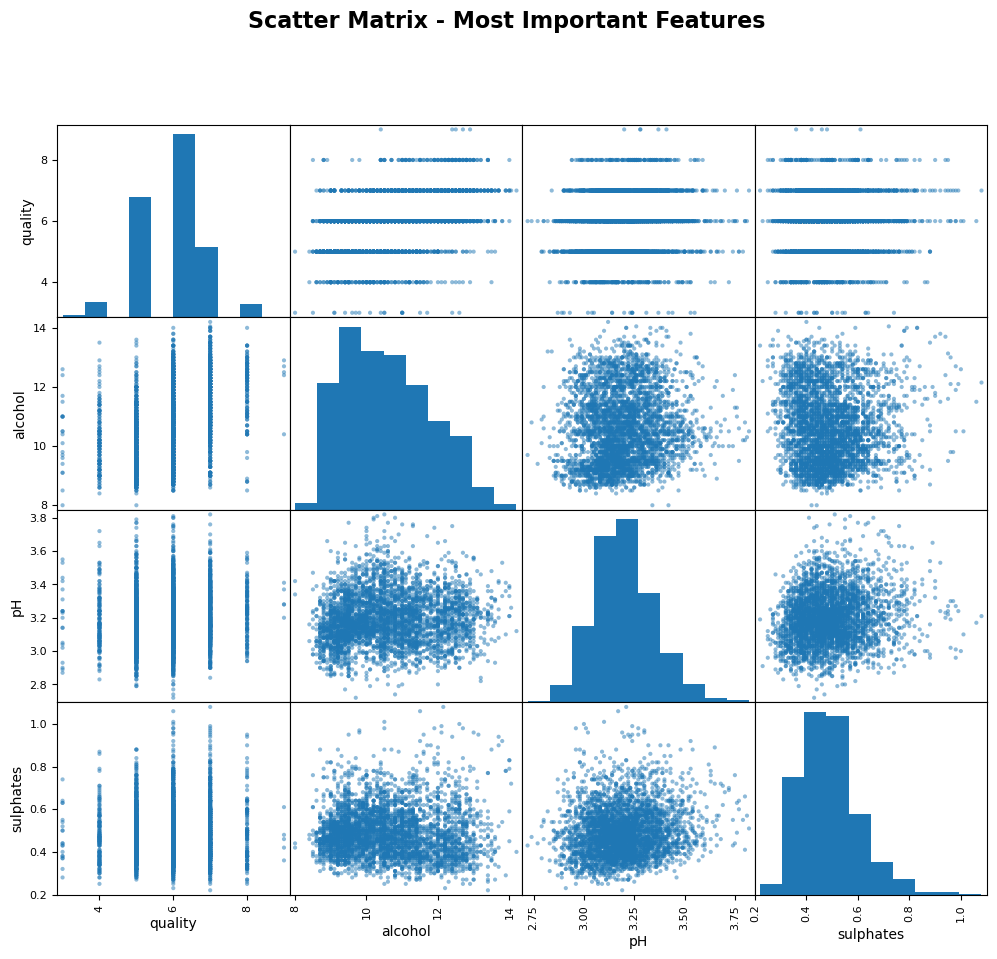


4. Highly Correlated Feature Pairs (potential multicollinearity):
   (Features with correlation > 0.7 or < -0.7)
   - residual_sugar <-> density: 0.8205
   - density <-> alcohol: -0.7602

------------------------------------------------------------
CORRELATION ANALYSIS COMPLETED ✓
------------------------------------------------------------

KEY INSIGHTS:
- Most positively correlated with quality: alcohol (0.463)
- Most negatively correlated with quality: density (-0.338)
- Found 2 highly correlated feature pairs (may indicate redundancy)


In [7]:
# ========== 1. COMPUTE CORRELATION MATRIX ==========
correlation_matrix = df.corr()  # Computes Pearson's r for all feature pairs
# Correlation Coefficient (r):
# - r = 1: Perfect positive correlation (when X increases, Y increases)
# - r = 0: No correlation (X and Y are independent)
# - r = -1: Perfect negative correlation (when X increases, Y decreases)
# Example: alcohol and quality have r≈0.48 (positively correlated)

# ========== 2. CORRELATION WITH TARGET ==========
# Check correlation of each feature with the target variable 'quality'
print("\n1. Correlation with Target (Quality):")
target_correlation = correlation_matrix['quality'].sort_values(ascending=False)
# Takes ONLY the 'quality' column from the Correlation Matrix
# .sort_values(ascending=False) sorts from HIGHEST to LOWEST correlation
print(target_correlation)
# Interpretation:
# - Positive values: Feature increases → Quality increases (e.g., alcohol)
# - Negative values: Feature increases → Quality decreases (e.g., volatile acidity)
# - Close to 0: Little to no linear relationship

# ========== 3. TOP 5 POSITIVELY CORRELATED ==========
print("\n2. Top 5 Features Most Correlated with Quality:")
top_correlations = target_correlation.drop('quality').head(5)
# .drop('quality') removes quality itself (always has r=1.0 with itself)
# .head(5) takes the first 5 entries (highest correlations)
for feature, corr in top_correlations.items():  # Iterate through feature name and correlation value
    print(f"   - {feature}: {corr:.4f}")  # .4f means: 4 decimal places

# ========== 4. TOP 5 NEGATIVELY CORRELATED ==========
print("\n3. Bottom 5 Features Least Correlated with Quality:")
bottom_correlations = target_correlation.drop('quality').tail(5)
# .tail(5) takes the last 5 entries (lowest/most negative correlations)
for feature, corr in bottom_correlations.items():
    print(f"   - {feature}: {corr:.4f}")

# ==========================================
# FIGURE 1: CORRELATION MATRIX HEATMAP
# ==========================================
# Géron uses scatter_matrix, but heatmap is better for papers
print("\n" + "-"*60)
print("Creating FIGURE 1: Correlation Matrix Heatmap")
print("-"*60)

plt.figure(figsize=(12, 10))  # Large figure (12x10 inches) because we have 12x12 matrix
sns.heatmap(correlation_matrix,  # The Correlation Matrix as heatmap
            annot=True,          # annot=True shows correlation values INSIDE the cells
            fmt='.2f',           # Format: 2 decimal places (e.g., 0.48 instead of 0.476543)
            cmap='coolwarm',     # Color scheme: Blue (negative) → White (0) → Red (positive)
            square=True,         # Make cells square-shaped (not rectangular)
            linewidths=0.5,      # 0.5 pixel wide lines between cells (better readability)
            cbar_kws={"shrink": 0.8},  # Colorbar 80% of figure height
            center=0,            # Center color scale at 0 (White = no correlation)
            vmin=-1, vmax=1)     # Min/Max values: -1 to +1 (Full range of Pearson's r)

# Formatting for better readability
plt.title('Figure 1: Feature Correlation Matrix - Wine Quality Dataset', 
          fontsize=14, fontweight='bold', pad=20)  # pad=20 adds space to the plot
plt.xticks(rotation=45, ha='right')  # X-axis labels rotated 45°, right-aligned
plt.yticks(rotation=0)  # Y-axis labels horizontal (0° rotation)
plt.tight_layout()  # Automatic layout (prevents cut-off labels)
plt.savefig('plots/01_exploratory/figure1_correlation_matrix.png', dpi=300, bbox_inches='tight')  # Save
# dpi=300 = high resolution for paper
# bbox_inches='tight' = crop white margins
print("✓ Figure 1 saved as 'figure1_correlation_matrix.png'")
print("  This figure shows correlations between all features.")
print("  - Red colors = positive correlation")
print("  - Blue colors = negative correlation")
print("  - The darker the color, the stronger the correlation")
plt.show()

# ==========================================
# ADDITIONAL: BAR CHART (like Géron's approach)
# ==========================================
print("\n" + "-"*60)
print("Creating Additional Visualization: Feature-Target Correlation")
print("-"*60)

plt.figure(figsize=(10, 8))  # New figure
# Sort features by ABSOLUTE correlation (|r|, ignores sign)
feature_target_corr = target_correlation.drop('quality').sort_values(key=abs, ascending=False)
# key=abs means: sort by absolute value
# ascending=False: highest |r| first

# Color based on sign: Green = positive, Red = negative
colors = ['green' if x > 0 else 'red' for x in feature_target_corr]
# List comprehension: for each value x, if x>0 then 'green', else 'red'

plt.barh(feature_target_corr.index, feature_target_corr.values, color=colors, alpha=0.7)
# .barh = horizontal bar chart (better for long feature names)
# .index = Feature names (Y-axis)
# .values = Correlation values (X-axis)
# alpha=0.7 = 70% opacity (slightly transparent)

plt.xlabel('Correlation with Wine Quality', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Correlation with Wine Quality (Target Variable)', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)  # Vertical line at x=0
# axvline = "axis vertical line"
# Helps to see which features are positively/negatively correlated
plt.grid(axis='x', alpha=0.3)  # Vertical grid lines (only X-axis), 30% transparent
plt.tight_layout()
plt.savefig('plots/01_exploratory/feature_target_correlation.png', dpi=300, bbox_inches='tight')
print("✓ Additional visualization saved as 'feature_target_correlation.png'")
print("  Green bars = positive correlation with quality")
print("  Red bars = negative correlation with quality")
plt.show()

# ==========================================
# SCATTER MATRIX (like in Géron's book!)
# ==========================================
# Géron: "Another way to check for correlation between attributes is to use
#         the pandas scatter_matrix() function"
print("\n" + "-"*60)
print("Creating Scatter Matrix (Géron Method)")
print("-"*60)

from pandas.plotting import scatter_matrix  # Import the scatter_matrix function

# Select the most important features for Scatter Matrix
# Géron: "let's just focus on a few promising attributes that seem most correlated"
# We take: quality (target) + top 3 correlated features
attributes = ['quality', 
              target_correlation.drop('quality').index[0],  # Top 1 Feature
              target_correlation.drop('quality').index[1],  # Top 2 Feature
              target_correlation.drop('quality').index[2]]  # Top 3 Feature

print(f"Selected attributes for scatter matrix: {attributes}")

# Create Scatter Matrix
scatter_matrix(df[attributes], figsize=(12, 10), diagonal='hist', alpha=0.5)
# df[attributes] = only the selected columns
# figsize=(12,10) = size of the figure
# diagonal='hist' = diagonal shows histograms (not scatter against itself)
# alpha=0.5 = 50% transparent (better visibility with many points)

# What does Scatter Matrix show?
# - Diagonal: Histogram of each feature (distribution)
# - Off-diagonal: Scatter plots between feature pairs
# - Helps visually identify correlations (linear relationships = points form a line)

plt.suptitle('Scatter Matrix - Most Important Features', fontsize=16, fontweight='bold', y=0.995)
# suptitle = "super title" for entire figure (above all subplots)
# y=0.995 positions title at the very top
plt.savefig('plots/01_exploratory/scatter_matrix_geron.png', dpi=300, bbox_inches='tight')
print("✓ Scatter matrix saved as 'scatter_matrix_geron.png'")
print("  Diagonal: Histograms showing feature distributions")
print("  Off-diagonal: Scatter plots showing feature relationships")
plt.show()

# ==========================================
# MULTICOLLINEARITY CHECK
# ==========================================
# Géron doesn't mention this explicitly, but it's important for Feature Selection
print("\n4. Highly Correlated Feature Pairs (potential multicollinearity):")
print("   (Features with correlation > 0.7 or < -0.7)")

threshold = 0.7  # Threshold for "high correlation"
# In literature: |r| > 0.7 is often considered "strongly correlated"
high_corr_pairs = []  # Empty list to store the pairs

# Iterate through all feature pairs
for i in range(len(correlation_matrix.columns)):  # Row index
    for j in range(i+1, len(correlation_matrix.columns)):  # Column index (only upper triangle matrix)
        # i+1 prevents duplicates (A-B and B-A) and self-correlation (A-A)
        if abs(correlation_matrix.iloc[i, j]) > threshold:  # abs() = absolute value
            # .iloc[i,j] = value at position (row i, column j)
            feature1 = correlation_matrix.columns[i]  # Name of Feature 1
            feature2 = correlation_matrix.columns[j]  # Name of Feature 2
            corr_value = correlation_matrix.iloc[i, j]  # Correlation value
            high_corr_pairs.append((feature1, feature2, corr_value))  # Store as tuple
            print(f"   - {feature1} <-> {feature2}: {corr_value:.4f}")
            # Interpretation: These features are redundant (provide similar information)

# If no highly correlated pairs found
if not high_corr_pairs:  # not high_corr_pairs = list is empty
    print("   No highly correlated feature pairs found (threshold = 0.7)")

# ==========================================
# SUMMARY
# ==========================================
print("\n" + "-"*60)
print("CORRELATION ANALYSIS COMPLETED ✓")
print("-"*60)
print("\nKEY INSIGHTS:")
# Reminder: Put these insights in our paper
print(f"- Most positively correlated with quality: {target_correlation.drop('quality').idxmax()} ({target_correlation.drop('quality').max():.3f})")
# .idxmax() returns the INDEX (feature name) of the maximum value
# .max() returns the maximum value itself
print(f"- Most negatively correlated with quality: {target_correlation.drop('quality').idxmin()} ({target_correlation.drop('quality').min():.3f})")
# .idxmin() and .min() for minimum
if high_corr_pairs:
    print(f"- Found {len(high_corr_pairs)} highly correlated feature pairs (may indicate redundancy)")
else:
    print("- No strong multicollinearity detected between features")


In [8]:

# Feature descriptions
# Correlation analysis
# Distribution plots


------------------------------------------------------------
2.3 DISTRIBUTION PLOTS
------------------------------------------------------------

Creating histograms for all features...
✓ Feature distribution plots saved as 'feature_distributions.png'
  Use this to identify:
  - Skewed distributions (most values on one side)
  - Normal/Gaussian distributions (bell curve)
  - Outliers (bars far from the main distribution)


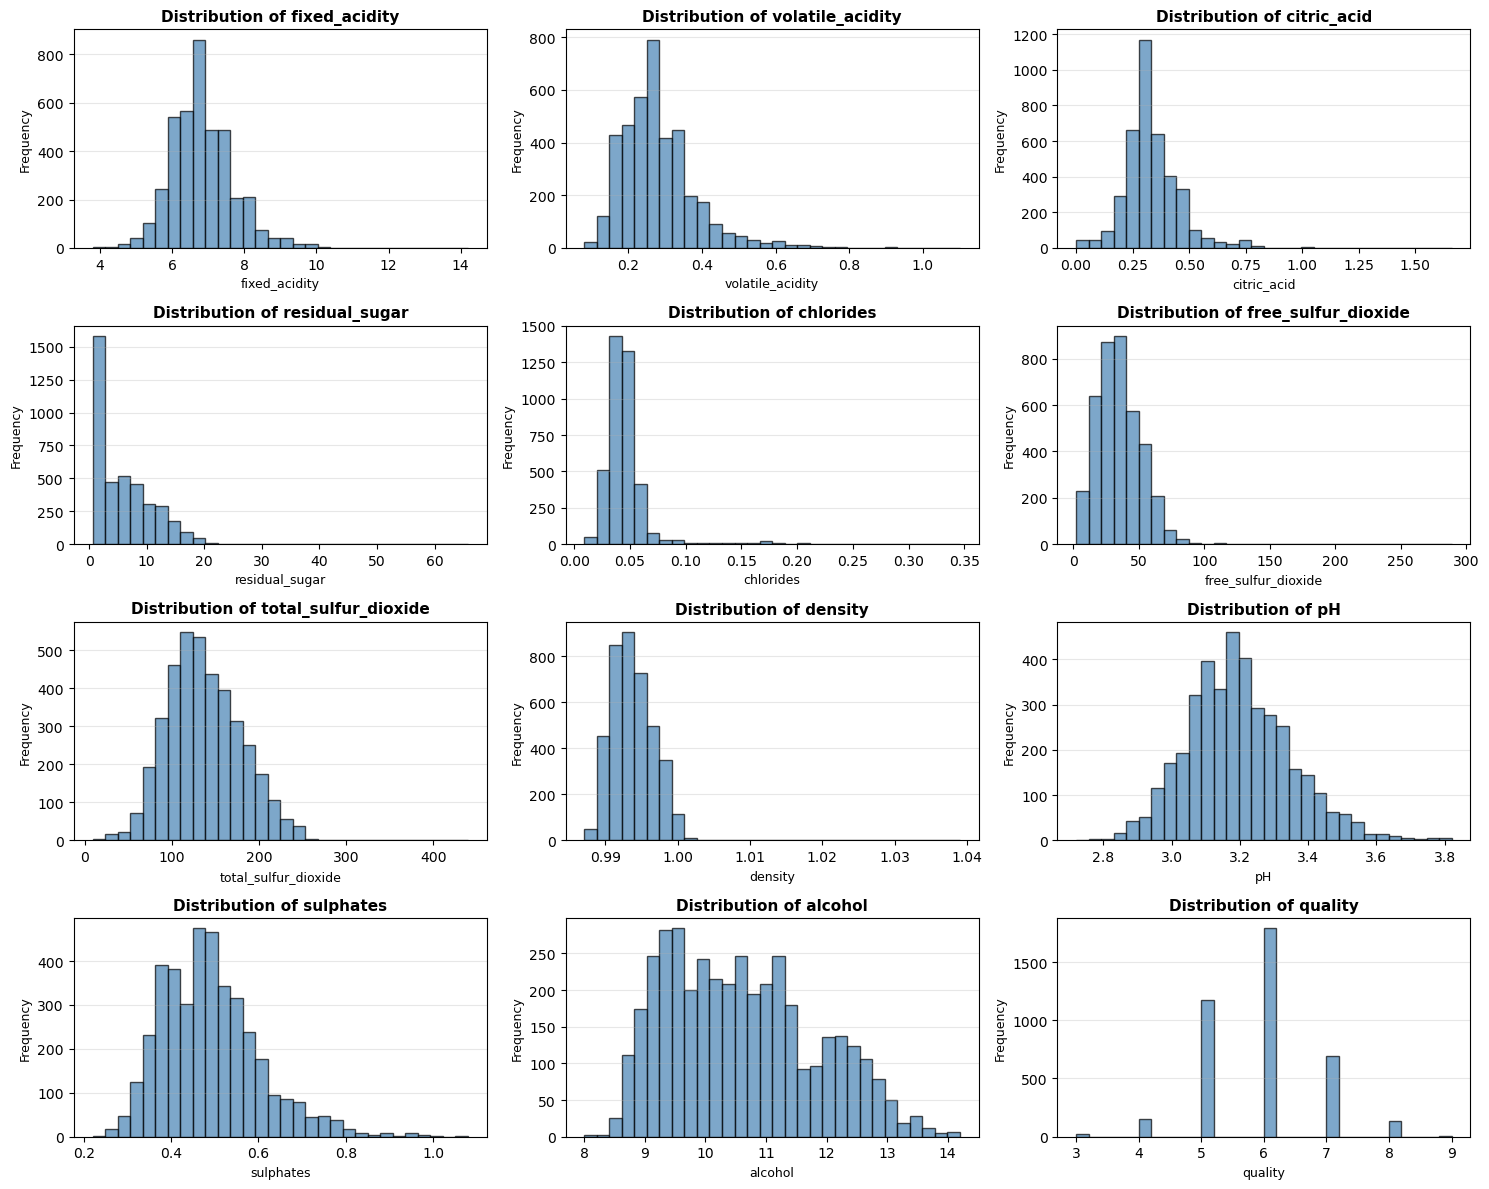


Creating box plots for outlier detection...
✓ Box plots saved as 'feature_boxplots.png'
  Red dots = outliers (values beyond 1.5*IQR from Q1/Q3)
  Red line in box = median value


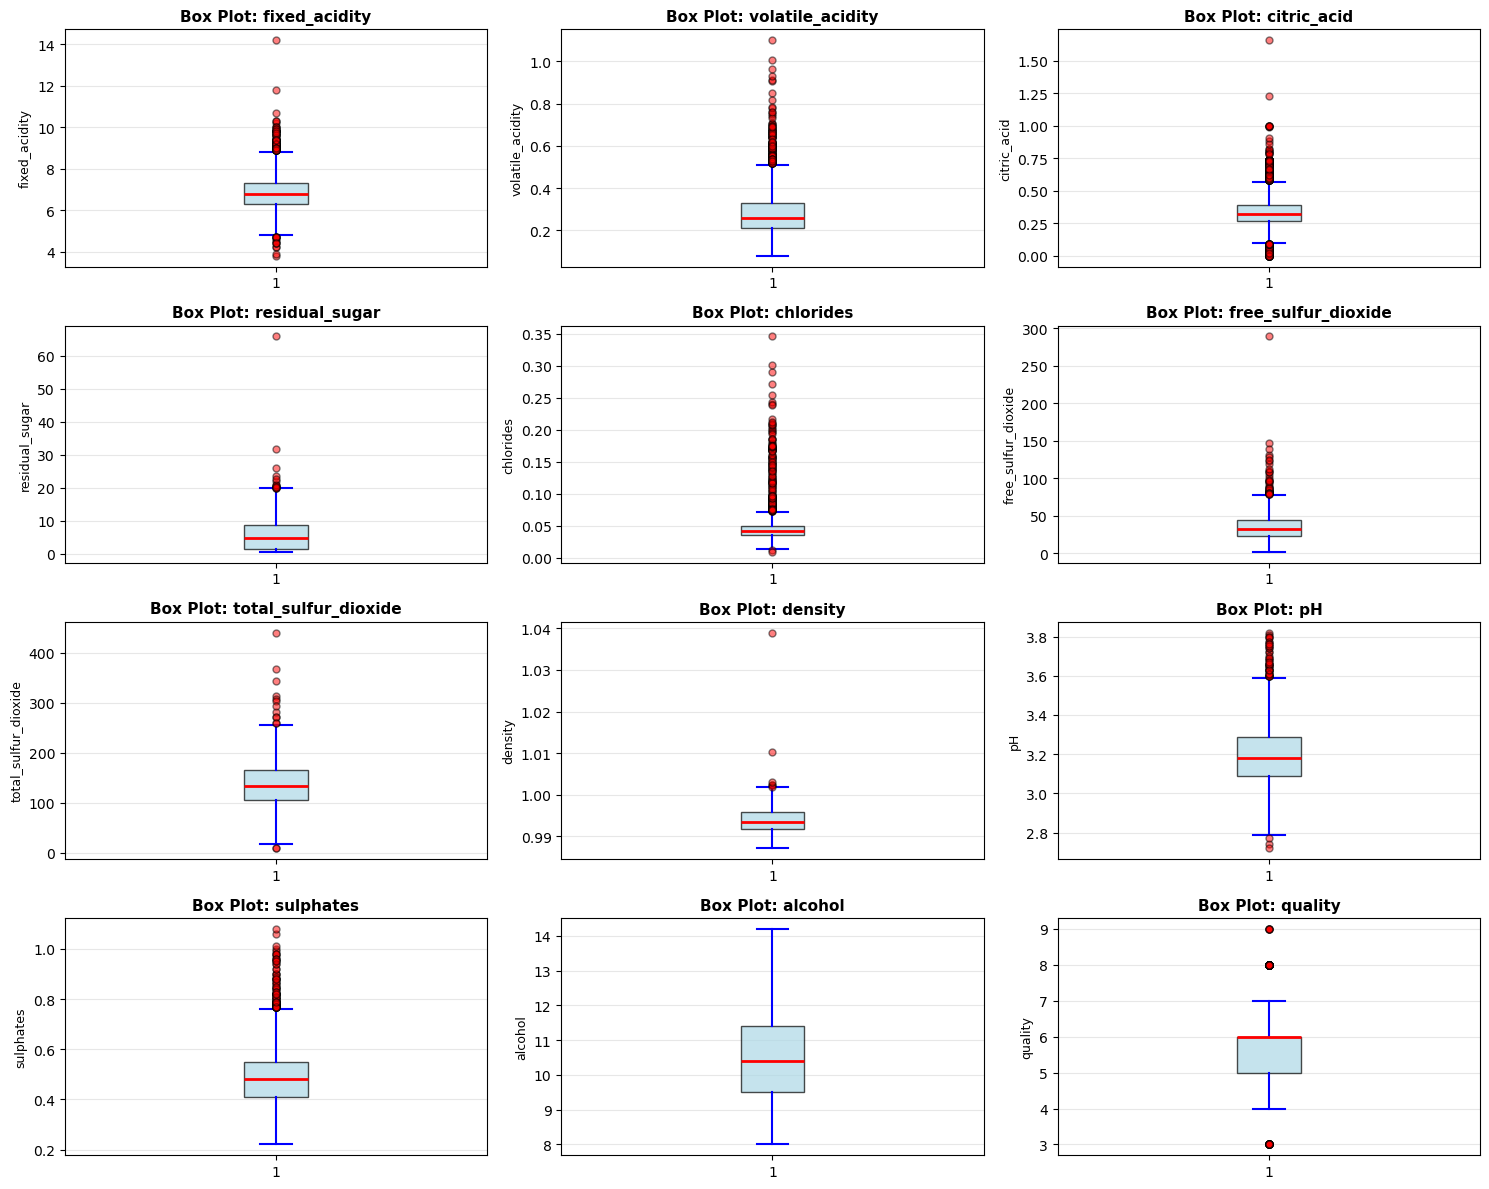


Calculating distribution statistics...

Distribution Statistics Table:
                                   Feature     Mean   Median     Std    Min  \
fixed_acidity                fixed_acidity    6.839    6.800   0.867  3.800   
volatile_acidity          volatile_acidity    0.281    0.260   0.103  0.080   
citric_acid                    citric_acid    0.334    0.320   0.122  0.000   
residual_sugar              residual_sugar    5.915    4.700   4.862  0.600   
chlorides                        chlorides    0.046    0.042   0.023  0.009   
free_sulfur_dioxide    free_sulfur_dioxide   34.889   33.000  17.210  2.000   
total_sulfur_dioxide  total_sulfur_dioxide  137.194  133.000  43.129  9.000   
density                            density    0.994    0.994   0.003  0.987   
pH                                      pH    3.195    3.180   0.152  2.720   
sulphates                        sulphates    0.490    0.480   0.114  0.220   
alcohol                            alcohol   10.589   10.40

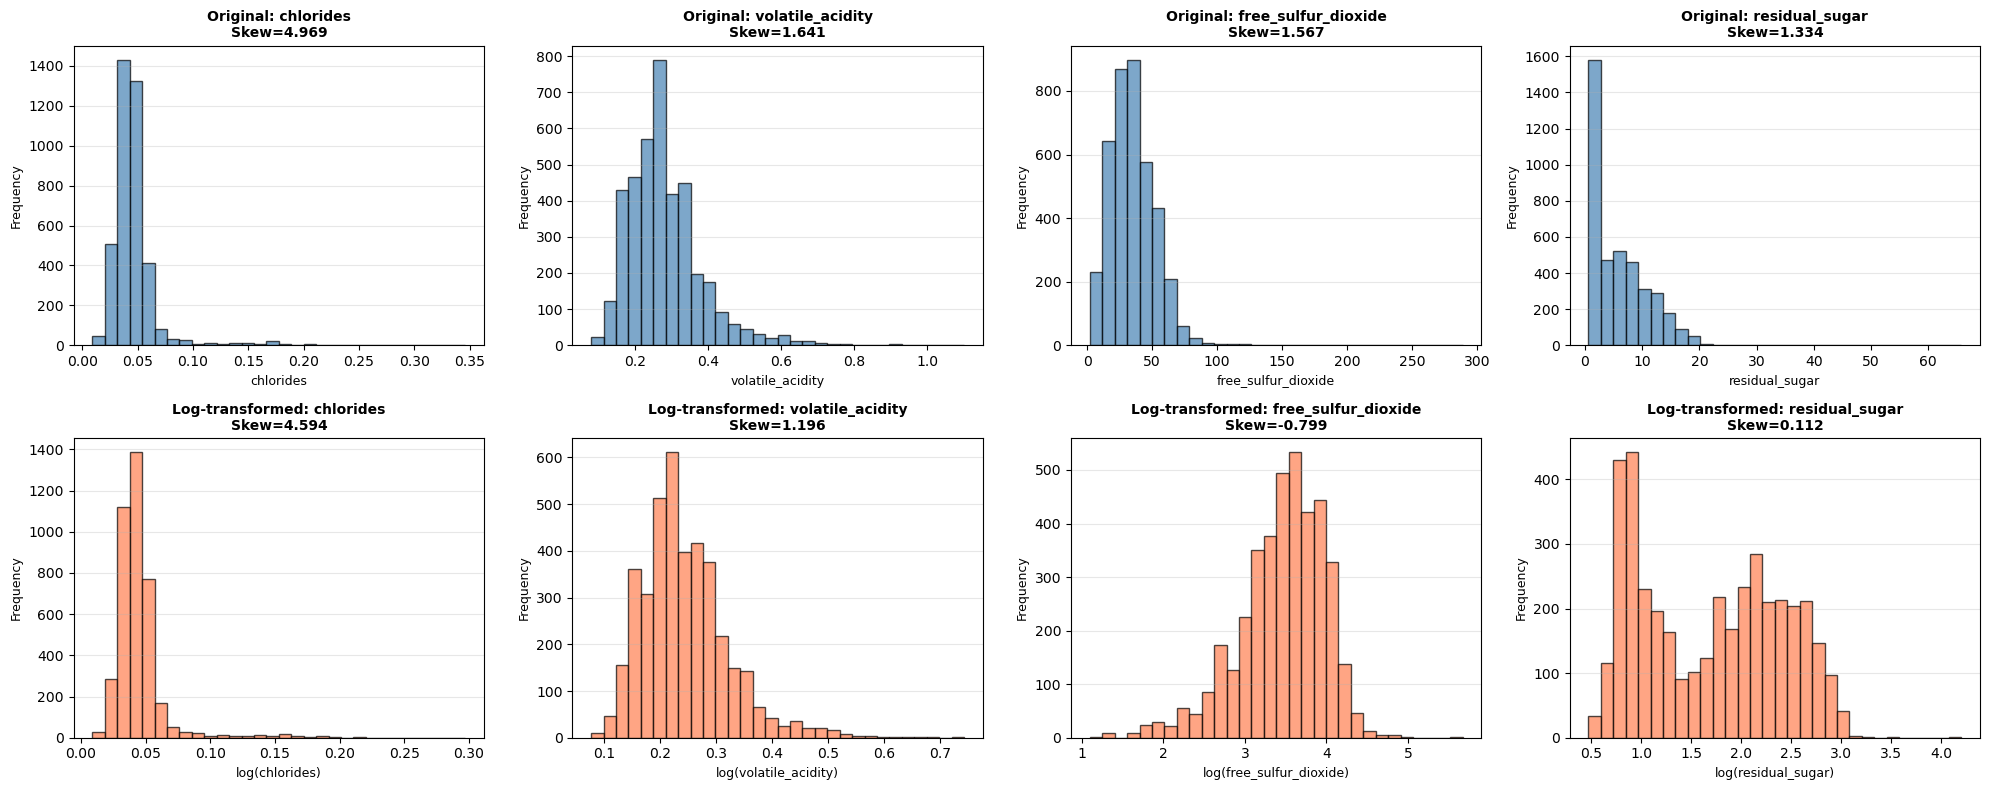


Creating KDE plots for all features...
✓ KDE plots saved as 'feature_kde_plots.png'
  Smooth curves show probability density
  Red dashed line = mean value


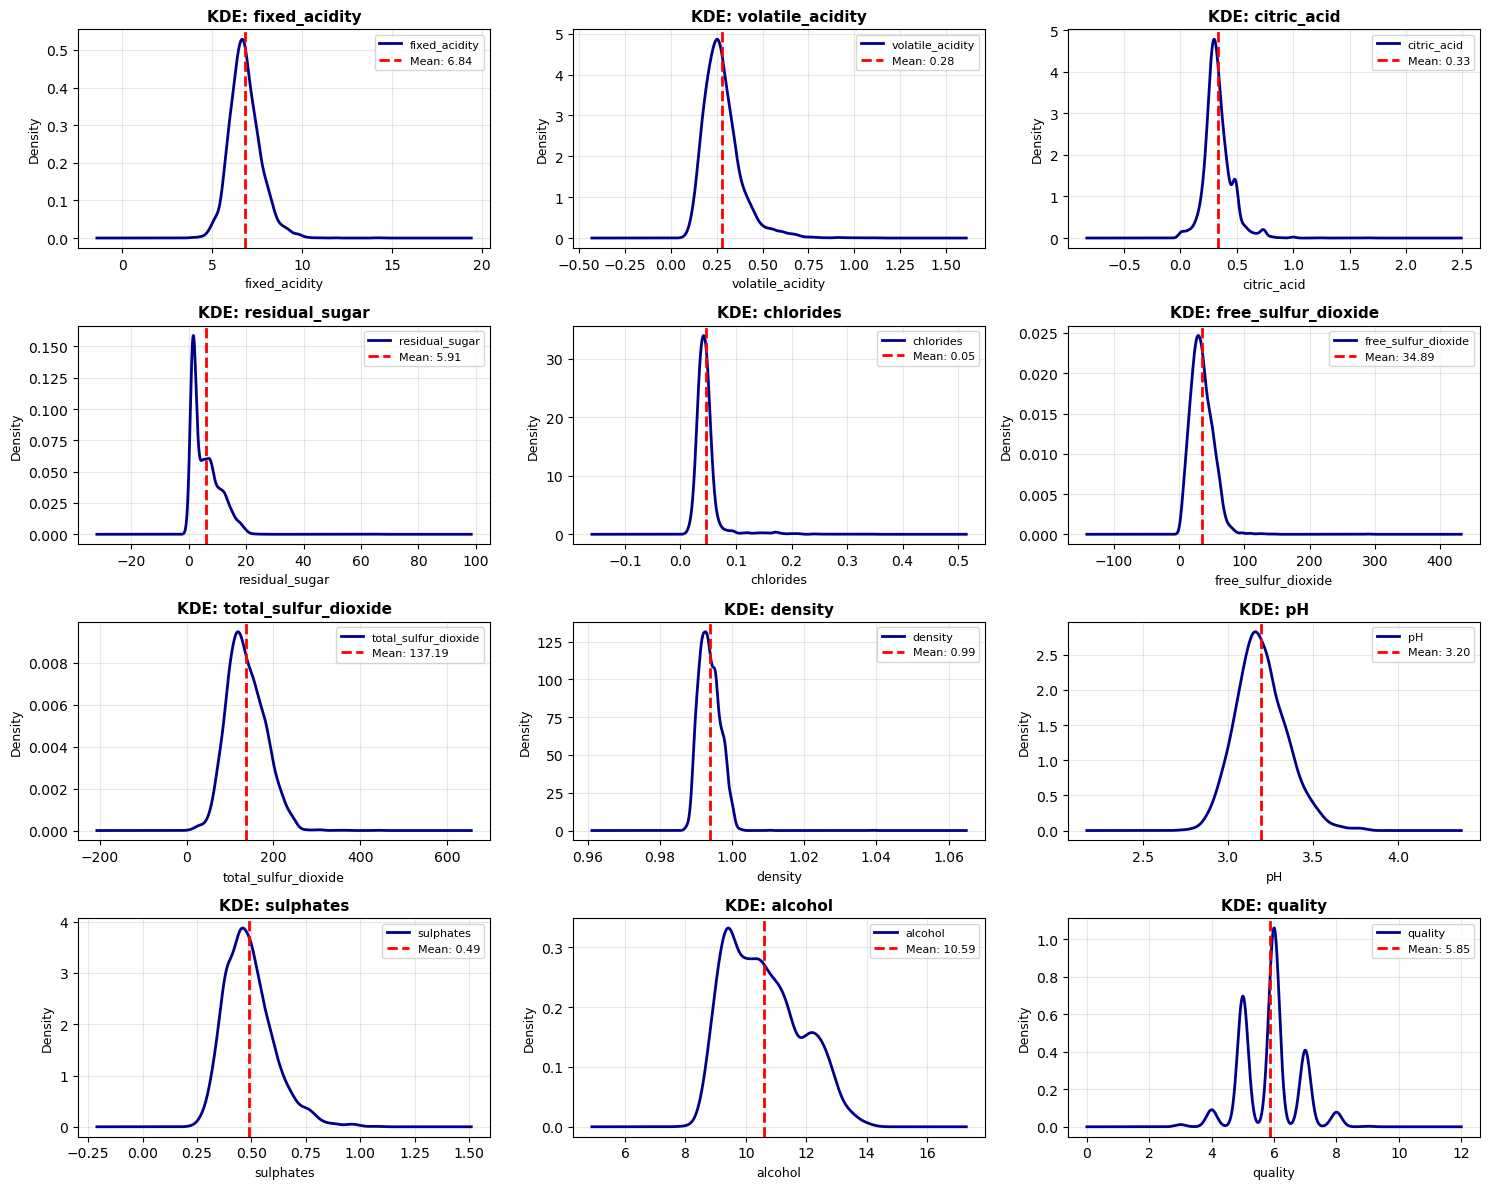


------------------------------------------------------------
DISTRIBUTION ANALYSIS COMPLETED ✓
------------------------------------------------------------

KEY INSIGHTS:
- Total features analyzed: 12
- Skewed features (|skew| > 0.5): 8
- Most skewed feature: chlorides (skew=4.969)

Outlier Summary:
  - fixed_acidity: 106 outliers (2.7%)
  - volatile_acidity: 133 outliers (3.4%)
  - citric_acid: 223 outliers (5.6%)
  - residual_sugar: 16 outliers (0.4%)
  - chlorides: 178 outliers (4.5%)
  - free_sulfur_dioxide: 44 outliers (1.1%)
  - total_sulfur_dioxide: 14 outliers (0.4%)
  - density: 6 outliers (0.2%)
  - pH: 46 outliers (1.2%)
  - sulphates: 96 outliers (2.4%)
  - quality: 156 outliers (3.9%)

Files Created:
  ✓ feature_distributions.png - Histograms of all features
  ✓ feature_boxplots.png - Box plots for outlier detection
  ✓ feature_kde_plots.png - Kernel Density Estimates
  ✓ distribution_statistics.csv - Statistical summary table
  ✓ skewed_features_comparison.png - Original

In [9]:
# ==========================================
# DISTRIBUTION PLOTS
# ==========================================
# Géron: "Visualizing data is one of the most important tasks in data exploration"
# Distribution plots help us understand:
# - Are features normally distributed? (important for some ML algorithms)
# - Are there outliers? (extreme values that might affect model)
# - What's the range and spread of each feature?
# - Are features on different scales? (important for scaling decision)

print("\n" + "-"*60) 
print("2.3 DISTRIBUTION PLOTS")
print("-"*60)

# ========== 1. HISTOGRAMS FOR ALL FEATURES ==========
# Histogram shows how values are distributed across bins (ranges)
# Géron: "The hist() method plots a histogram for each numerical attribute"

print("\nCreating histograms for all features...")

# Create a grid of subplots: 4 rows x 3 columns = 12 plots (11 features + 1 target)
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
# subplots(4, 3) creates a 4x3 grid of plots
# figsize=(15, 12) makes the entire figure 15 inches wide, 12 inches tall
axes = axes.ravel()  # Flatten the 2D array of axes into 1D array for easier iteration
# .ravel() converts [[ax1, ax2, ax3], [ax4, ax5, ax6], ...] to [ax1, ax2, ax3, ax4, ...]

# Plot histogram for each feature
for idx, col in enumerate(df.columns):  # enumerate gives us both index and column name
    # idx = index (0, 1, 2, ...), col = column name ('fixed acidity', 'volatile acidity', ...)
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    # .hist() creates histogram
    # bins=30 divides the data range into 30 bins/buckets
    # edgecolor='black' adds black borders around bars (better visibility)
    # alpha=0.7 = 70% opacity (slightly transparent)
    # color='steelblue' makes bars blue
    
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    # Title for each subplot
    axes[idx].set_xlabel(col, fontsize=9)  # X-axis label
    axes[idx].set_ylabel('Frequency', fontsize=9)  # Y-axis label (count of samples)
    axes[idx].grid(axis='y', alpha=0.3)  # Add horizontal grid lines, 30% transparent

# Hide the last subplot if we have an odd number of features
# (We have 12 features total, so all subplots are used)
if len(df.columns) < len(axes):  # If features < subplots
    for idx in range(len(df.columns), len(axes)):  # Hide unused subplots
        axes[idx].set_visible(False)

plt.tight_layout()  # Adjust spacing to prevent overlapping labels
plt.savefig('plots/01_exploratory/feature_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Feature distribution plots saved as 'feature_distributions.png'")
print("  Use this to identify:")
print("  - Skewed distributions (most values on one side)")
print("  - Normal/Gaussian distributions (bell curve)")
print("  - Outliers (bars far from the main distribution)")
plt.show()

# ========== 2. BOX PLOTS FOR OUTLIER DETECTION ==========
# Box plots (also called box-and-whisker plots) show:
# - Median (middle line in box)
# - Q1 and Q3 (box edges = 25th and 75th percentiles)
# - IQR (Interquartile Range = Q3 - Q1)
# - Outliers (points beyond whiskers)
# Géron mentions outliers: "You may want to remove outliers or cap them"

print("\nCreating box plots for outlier detection...")

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    axes[idx].boxplot(df[col], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(color='blue', linewidth=1.5),
                      capprops=dict(color='blue', linewidth=1.5),
                      flierprops=dict(marker='o', markerfacecolor='red', 
                                     markersize=5, alpha=0.5))
    # .boxplot() creates box-and-whisker plot
    # vert=True makes it vertical
    # patch_artist=True allows us to color the box
    # boxprops sets box appearance (light blue, 70% opacity)
    # medianprops sets median line (red, thick)
    # whiskerprops sets whisker lines (blue)
    # capprops sets cap lines at whisker ends
    # flierprops sets outlier point appearance (red circles)
    
    axes[idx].set_title(f'Box Plot: {col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide unused subplots
if len(df.columns) < len(axes):
    for idx in range(len(df.columns), len(axes)):
        axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('plots/01_exploratory/feature_boxplots.png', dpi=300, bbox_inches='tight')
print("✓ Box plots saved as 'feature_boxplots.png'")
print("  Red dots = outliers (values beyond 1.5*IQR from Q1/Q3)")
print("  Red line in box = median value")
plt.show()

# ========== 3. DISTRIBUTION STATISTICS SUMMARY ==========
# Calculate skewness and kurtosis for each feature
# - Skewness: measures asymmetry of distribution
#   * Skew = 0: symmetric (normal distribution)
#   * Skew > 0: right-skewed (long tail on right)
#   * Skew < 0: left-skewed (long tail on left)
# - Kurtosis: measures "tailedness" (how much data in tails vs. center)
#   * Kurtosis = 0: normal distribution
#   * Kurtosis > 0: heavy tails (more outliers)
#   * Kurtosis < 0: light tails (fewer outliers)

print("\nCalculating distribution statistics...")

from scipy import stats  # Import scipy for skewness and kurtosis

distribution_stats = pd.DataFrame({
    'Feature': df.columns,
    'Mean': df.mean(),
    'Median': df.median(),
    'Std': df.std(),
    'Min': df.min(),
    'Max': df.max(),
    'Skewness': df.skew(),  # .skew() calculates skewness
    'Kurtosis': df.kurtosis()  # .kurtosis() calculates kurtosis
})

print("\nDistribution Statistics Table:")
print(distribution_stats.round(3))  # Round to 3 decimal places
distribution_stats.to_csv('results/distribution_statistics.csv', index=False)
print("\n✓ Distribution statistics saved as 'distribution_statistics.csv'")

# ========== 4. IDENTIFY SKEWED FEATURES ==========
# Features with |skewness| > 0.5 are considered moderately skewed
# Features with |skewness| > 1.0 are considered highly skewed
# Skewed features might need transformation (log, sqrt, Box-Cox)

print("\n" + "="*60)
print("SKEWNESS ANALYSIS")
print("="*60)

skewed_features = distribution_stats[abs(distribution_stats['Skewness']) > 0.5].sort_values('Skewness', key=abs, ascending=False)
# abs(Skewness) > 0.5 filters features with moderate to high skewness
# sort_values by absolute skewness descending

if len(skewed_features) > 0:
    print(f"\nFound {len(skewed_features)} skewed features (|skewness| > 0.5):")
    for _, row in skewed_features.iterrows():  # Iterate through each row
        skew_val = row['Skewness']
        skew_type = "right-skewed" if skew_val > 0 else "left-skewed"
        print(f"  - {row['Feature']}: {skew_val:.3f} ({skew_type})")
    
    print("\nNote: Skewed features may benefit from transformations:")
    print("  - Right-skewed (positive): log transform, sqrt transform")
    print("  - Left-skewed (negative): square transform, exponential transform")
else:
    print("\nNo highly skewed features detected (all |skewness| < 0.5)")

# ========== 5. VISUALIZE SKEWED FEATURES (if any) ==========
if len(skewed_features) > 0:
    print("\nCreating comparison plots for most skewed features...")
    
    # Take top 4 most skewed features (or fewer if less than 4)
    top_skewed = skewed_features.head(min(4, len(skewed_features)))
    
    fig, axes = plt.subplots(2, len(top_skewed), figsize=(5*len(top_skewed), 8))
    # Create 2 rows: original distribution (top) and log-transformed (bottom)
    
    if len(top_skewed) == 1:  # If only 1 feature, axes is 1D array
        axes = axes.reshape(-1, 1)  # Make it 2D array for consistent indexing
    
    for idx, (_, row) in enumerate(top_skewed.iterrows()):
        feature = row['Feature']
        
        # Top row: Original distribution
        axes[0, idx].hist(df[feature], bins=30, color='steelblue', 
                         edgecolor='black', alpha=0.7)
        axes[0, idx].set_title(f'Original: {feature}\nSkew={row["Skewness"]:.3f}', 
                              fontsize=10, fontweight='bold')
        axes[0, idx].set_xlabel(feature, fontsize=9)
        axes[0, idx].set_ylabel('Frequency', fontsize=9)
        axes[0, idx].grid(axis='y', alpha=0.3)
        
        # Bottom row: Log-transformed distribution (if all values are positive)
        if df[feature].min() > 0:  # Log only works for positive values
            log_transformed = np.log1p(df[feature])  # log1p = log(1+x), handles zeros better
            new_skew = log_transformed.skew()
            axes[1, idx].hist(log_transformed, bins=30, color='coral', 
                            edgecolor='black', alpha=0.7)
            axes[1, idx].set_title(f'Log-transformed: {feature}\nSkew={new_skew:.3f}', 
                                  fontsize=10, fontweight='bold')
            axes[1, idx].set_xlabel(f'log({feature})', fontsize=9)
            axes[1, idx].set_ylabel('Frequency', fontsize=9)
            axes[1, idx].grid(axis='y', alpha=0.3)
        else:
            axes[1, idx].text(0.5, 0.5, 'Cannot apply log\n(contains negatives)', 
                            ha='center', va='center', fontsize=10)
            axes[1, idx].set_xticks([])
            axes[1, idx].set_yticks([])
    
    plt.tight_layout()
    plt.savefig('plots/01_exploratory/skewed_features_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Skewed features comparison saved as 'skewed_features_comparison.png'")
    print("  Top: Original distribution")
    print("  Bottom: Log-transformed distribution (reduced skewness)")
    plt.show()

# ========== 6. KERNEL DENSITY ESTIMATE (KDE) PLOTS ==========
# KDE is a smoothed version of histogram - shows continuous probability density
# Géron: "Kernel Density Estimation plots provide a smooth estimate of the distribution"

print("\nCreating KDE plots for all features...")

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    df[col].plot(kind='kde', ax=axes[idx], color='darkblue', linewidth=2)
    # .plot(kind='kde') creates Kernel Density Estimate plot
    # Smoothed curve showing probability density
    axes[idx].set_title(f'KDE: {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=9)
    axes[idx].set_ylabel('Density', fontsize=9)
    axes[idx].grid(alpha=0.3)
    
    # Add a vertical line for mean
    mean_val = df[col].mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', 
                     linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].legend(fontsize=8)

# Hide unused subplots
if len(df.columns) < len(axes):
    for idx in range(len(df.columns), len(axes)):
        axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('plots/01_exploratory/feature_kde_plots.png', dpi=300, bbox_inches='tight')
print("✓ KDE plots saved as 'feature_kde_plots.png'")
print("  Smooth curves show probability density")
print("  Red dashed line = mean value")
plt.show()

# ==========================================
# SUMMARY
# ==========================================
print("\n" + "-"*60)
print("DISTRIBUTION ANALYSIS COMPLETED ✓")
print("-"*60)
print("\nKEY INSIGHTS:")
print(f"- Total features analyzed: {len(df.columns)}")
print(f"- Skewed features (|skew| > 0.5): {len(skewed_features)}")
if len(skewed_features) > 0:
    most_skewed = skewed_features.iloc[0]
    print(f"- Most skewed feature: {most_skewed['Feature']} (skew={most_skewed['Skewness']:.3f})")

# Check for features with extreme outliers
print("\nOutlier Summary:")
for col in df.columns:
    Q1 = df[col].quantile(0.25)  # 25th percentile
    Q3 = df[col].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1  # Interquartile Range
    lower_bound = Q1 - 1.5 * IQR  # Lower outlier boundary
    upper_bound = Q3 + 1.5 * IQR  # Upper outlier boundary
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    # Count values beyond boundaries
    if len(outliers) > 0:
        print(f"  - {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

print("\nFiles Created:")
print("  ✓ feature_distributions.png - Histograms of all features")
print("  ✓ feature_boxplots.png - Box plots for outlier detection")
print("  ✓ feature_kde_plots.png - Kernel Density Estimates")
print("  ✓ distribution_statistics.csv - Statistical summary table")
if len(skewed_features) > 0:
    print("  ✓ skewed_features_comparison.png - Original vs Log-transformed")


In [10]:
# ============================================================
# 3. PREPROCESSING
# ============================================================
# CRITICAL: Follow this exact order (as per assignment requirements)
# 1. Handle missing values
# 2. Treat outliers
# 3. Feature scaling
# 4. Train/test split (BEFORE feature selection!)
# Géron: "It is crucial to create a test set before looking at the data closely"

print("\n" + "="*60)
print("3. PREPROCESSING")
print("="*60)

# ------------------------------------------------------------
# 3.1 HANDLE MISSING VALUES
# ------------------------------------------------------------
# Check for missing values in the dataset
# Missing values can cause errors in ML algorithms
# Common strategies: drop rows, impute with mean/median, or use advanced imputation

print("\n" + "-"*60)
print("3.1 HANDLE MISSING VALUES")
print("-"*60)

print("\nChecking for missing values...")
missing_count = df.isnull().sum()  # Count missing values per column
# .isnull() returns True/False for each cell (True if missing)
# .sum() counts the True values (missing values) per column

missing_percentage = (missing_count / len(df)) * 100  # Calculate percentage
# Divide by total rows, multiply by 100 to get percentage

# Create summary DataFrame
missing_summary = pd.DataFrame({
    'Feature': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_Percentage': missing_percentage.values
})

# Filter to show only features with missing values
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

if len(missing_summary) > 0:
    print(f"\nFound missing values in {len(missing_summary)} features:")
    print(missing_summary.to_string(index=False))
    
    print("\nStrategy: Impute missing values with median (robust to outliers)")
    # Median is better than mean for skewed distributions (less affected by outliers)
    
    for col in missing_summary['Feature']:
        median_value = df[col].median()  # Calculate median of the column
        df[col].fillna(median_value, inplace=True)  # Replace NaN with median
        # .fillna() replaces missing values
        # inplace=True modifies the original DataFrame
        print(f"  - {col}: Filled {missing_count[col]} missing values with median={median_value:.2f}")
    
    # Verify no missing values remain
    print(f"\nVerification: Missing values after imputation = {df.isnull().sum().sum()}")
    # .sum().sum() = sum across columns, then sum the result (total missing values)
else:
    print("\n✓ No missing values detected in the dataset")
    print("  All features are complete - no imputation needed")

# ------------------------------------------------------------
# 3.2 TREAT OUTLIERS
# ------------------------------------------------------------
# Outliers are extreme values that can distort model performance
# Detection method: IQR (Interquartile Range) method
# - Values < Q1 - 1.5*IQR or > Q3 + 1.5*IQR are considered outliers
# Géron: "You may want to remove outliers or cap them"

print("\n" + "-"*60)
print("3.2 TREAT OUTLIERS")
print("-"*60)

print("\nDetecting outliers using IQR method (1.5*IQR rule)...")

# Separate features (X) and target (y) before outlier treatment
X = df.drop('quality', axis=1)  # Features only (without target)
y = df['quality']  # Target variable

# Store outlier information for each feature
outlier_summary = []

for col in X.columns:  # Iterate through each feature
    Q1 = X[col].quantile(0.25)  # First quartile (25th percentile)
    Q3 = X[col].quantile(0.75)  # Third quartile (75th percentile)
    IQR = Q3 - Q1  # Interquartile Range (spread of middle 50%)
    
    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR  # Lower threshold
    upper_bound = Q3 + 1.5 * IQR  # Upper threshold
    
    # Count outliers
    outliers_mask = (X[col] < lower_bound) | (X[col] > upper_bound)
    # | = OR operator (outliers below lower OR above upper bound)
    outlier_count = outliers_mask.sum()  # Count True values
    outlier_percentage = (outlier_count / len(X)) * 100
    
    if outlier_count > 0:
        outlier_summary.append({
            'Feature': col,
            'Outlier_Count': outlier_count,
            'Outlier_Percentage': outlier_percentage,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })

if len(outlier_summary) > 0:
    outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Count', ascending=False)
    print(f"\nFound outliers in {len(outlier_summary)} features:")
    print(outlier_df.round(2).to_string(index=False))
    
    print("\n" + "-"*60)
    print("OUTLIER TREATMENT DECISION:")
    print("-"*60)
    print("Strategy: KEEP outliers (do not remove)")
    print("Justification:")
    print("  1. Wine Quality Context: Outliers may represent exceptional wines")
    print("     - High alcohol content = premium wines")
    print("     - High acidity = specific wine styles (e.g., Champagne)")
    print("  2. Random Forest Model: Robust to outliers (tree-based, not distance-based)")
    print("  3. Small Dataset: Removing outliers would lose valuable data (1599 samples)")
    print("  4. Real-world Variation: Outliers are part of natural wine diversity")
    print("\nNote: This decision will be justified in the paper's methodology section")
    
    # Optional: Show example of most extreme outliers
    most_outliers_feature = outlier_df.iloc[0]['Feature']
    print(f"\nExample: '{most_outliers_feature}' has {outlier_df.iloc[0]['Outlier_Count']} outliers")
    print(f"  - Lower bound: {outlier_df.iloc[0]['Lower_Bound']:.2f}")
    print(f"  - Upper bound: {outlier_df.iloc[0]['Upper_Bound']:.2f}")
    
else:
    print("\n✓ No outliers detected using IQR method (1.5*IQR rule)")

# Store outlier summary for later reference
outlier_df.to_csv('results/outlier_summary.csv', index=False) if len(outlier_summary) > 0 else None
if len(outlier_summary) > 0:
    print("\n✓ Outlier summary saved as 'outlier_summary.csv'")

# ------------------------------------------------------------
# 3.3 FEATURE SCALING
# ------------------------------------------------------------
# IMPORTANT: Scale AFTER train/test split to prevent data leakage!
# Data leakage = when information from test set influences training
# We'll prepare for scaling here, but apply AFTER split

print("\n" + "-"*60)
print("3.3 FEATURE SCALING (Preparation)")
print("-"*60)

print("\nAnalyzing feature scales to determine scaling strategy...")

# Check the range of each feature
scale_analysis = pd.DataFrame({
    'Feature': X.columns,
    'Min': X.min(),
    'Max': X.max(),
    'Range': X.max() - X.min(),
    'Mean': X.mean(),
    'Std': X.std()
})

print("\nFeature Scale Analysis:")
print(scale_analysis.round(2).to_string(index=False))

# Check if features are on different scales
max_range = scale_analysis['Range'].max()
min_range = scale_analysis['Range'].min()
scale_ratio = max_range / min_range
# If ratio > 10, features are on very different scales

print(f"\n" + "-"*60)
print("SCALING DECISION:")
print("-"*60)
print(f"Scale range ratio: {scale_ratio:.2f} (max range / min range)")

if scale_ratio > 10:
    print("✓ Scaling is REQUIRED")
    print("  Features have very different scales (ratio > 10)")
    print(f"  Example: '{scale_analysis.loc[scale_analysis['Range'].idxmax(), 'Feature']}' ")
    print(f"           range = {scale_analysis['Range'].max():.2f}")
    print(f"           vs '{scale_analysis.loc[scale_analysis['Range'].idxmin(), 'Feature']}' ")
    print(f"           range = {scale_analysis['Range'].min():.2f}")
else:
    print("✓ Scaling is RECOMMENDED for consistency")
    print("  Even though scales are similar, standardization helps many algorithms")

print("\nScaling Method: StandardScaler (z-score normalization)")
print("  Formula: z = (x - mean) / std")
print("  Result: Mean = 0, Std = 1 for all features")
print("  Why: Suitable for features with different ranges and approximately normal distributions")
print("  Alternative: MinMaxScaler (scales to [0,1]) - not used here")

print("\nNote: Scaling will be applied AFTER train/test split (Step 3.4) to prevent data leakage")

# Save scale analysis
scale_analysis.round(2).to_csv('results/feature_scale_analysis.csv', index=False)
print("\n✓ Feature scale analysis saved as 'feature_scale_analysis.csv'")

# ------------------------------------------------------------
# 3.4 TRAIN/TEST SPLIT
# ------------------------------------------------------------
# CRITICAL: Split BEFORE any feature selection or engineering!
# Géron: "Create a test set, put it aside, and never look at it"
# This prevents overfitting and ensures honest evaluation

print("\n" + "-"*60)
print("3.4 TRAIN/TEST SPLIT")
print("-"*60)

print(f"\nSplitting dataset: {100-TEST_SIZE*100:.0f}% train / {TEST_SIZE*100:.0f}% test")
print(f"Random state: {RANDOM_STATE} (for reproducibility)")

# Perform stratified split
# Stratified = maintains same class distribution in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,  # Features and target
    test_size=TEST_SIZE,  # 20% for testing (0.2)
    random_state=RANDOM_STATE,  # Seed for reproducibility (42)
    stratify=y  # Maintain target distribution
)
# train_test_split() randomly splits data into train and test sets
# stratify=y ensures both sets have similar quality score distributions

print("\n" + "-"*60)
print("SPLIT SUMMARY:")
print("-"*60)
print(f"Original dataset size: {len(df)} samples")
print(f"Training set size: {len(X_train)} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test set size: {len(X_test)} samples ({len(X_test)/len(df)*100:.1f}%)")

# Check stratification worked
print("\nTarget Distribution Verification (stratification check):")
print("\nTraining set quality distribution:")
print(y_train.value_counts().sort_index())
train_dist = y_train.value_counts(normalize=True).sort_index() * 100
# normalize=True converts counts to percentages

print("\nTest set quality distribution:")
print(y_test.value_counts().sort_index())
test_dist = y_test.value_counts(normalize=True).sort_index() * 100

print("\nPercentage comparison:")
comparison_df = pd.DataFrame({
    'Quality': train_dist.index,
    'Train_%': train_dist.values,
    'Test_%': test_dist.values,
    'Difference': abs(train_dist.values - test_dist.values)
})
print(comparison_df.round(2).to_string(index=False))

max_diff = comparison_df['Difference'].max()
if max_diff < 5:  # Less than 5% difference
    print(f"\n✓ Stratification successful: Max difference = {max_diff:.2f}%")
else:
    print(f"\n⚠ Warning: Large distribution difference = {max_diff:.2f}%")

# ------------------------------------------------------------
# 3.5 APPLY FEATURE SCALING
# ------------------------------------------------------------
# Now that data is split, we can safely scale
# Fit scaler on TRAINING data only, then transform both train and test
# This prevents data leakage (test data doesn't influence scaling parameters)

print("\n" + "-"*60)
print("3.5 APPLY FEATURE SCALING")
print("-"*60)

print("\nInitializing StandardScaler...")
scaler = StandardScaler()  # Create scaler object
# StandardScaler will compute mean and std from training data

print("Fitting scaler on training data and transforming both sets...")

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)
# .fit_transform() = .fit() + .transform()
# .fit() learns mean and std from X_train
# .transform() applies the scaling: (x - mean) / std

# Transform test data using training statistics
X_test_scaled = scaler.transform(X_test)
# .transform() only (no fit!) - uses mean/std from training data
# This is crucial: test data must not influence scaling parameters

# Convert back to DataFrame for easier handling (keeps column names)
X_train_scaled = pd.DataFrame(
    X_train_scaled, 
    columns=X.columns,  # Restore column names
    index=X_train.index  # Restore row indices
)

X_test_scaled = pd.DataFrame(
    X_test_scaled, 
    columns=X.columns, 
    index=X_test.index
)

print("\n" + "-"*60)
print("SCALING VERIFICATION:")
print("-"*60)

# Verify scaling worked (means should be ~0, stds should be ~1)
scaling_verification = pd.DataFrame({
    'Feature': X.columns,
    'Train_Mean': X_train_scaled.mean(),
    'Train_Std': X_train_scaled.std(),
    'Test_Mean': X_test_scaled.mean(),
    'Test_Std': X_test_scaled.std()
})

print("\nScaled statistics (should be Mean≈0, Std≈1):")
print(scaling_verification.round(3).to_string(index=False))

# Check if scaling was successful
mean_check = abs(X_train_scaled.mean().mean()) < 0.01  # Mean should be near 0
# .mean().mean() = mean of all features, then mean of that
std_check = abs(X_train_scaled.std().mean() - 1.0) < 0.1  # Std should be near 1

if mean_check and std_check:
    print("\n✓ Scaling successful:")
    print(f"  - Average mean across features: {X_train_scaled.mean().mean():.6f} (target: 0)")
    print(f"  - Average std across features: {X_train_scaled.std().mean():.6f} (target: 1)")
else:
    print("\n⚠ Warning: Scaling results unexpected. Check data.")

# Save scaling verification
scaling_verification.round(3).to_csv('results/scaling_verification.csv', index=False)
print("\n✓ Scaling verification saved as 'scaling_verification.csv'")

# ============================================================
# PREPROCESSING COMPLETED
# ============================================================
print("\n" + "-"*60)
print("PREPROCESSING COMPLETED ✓")
print("-"*60)

print("\nKEY INSIGHTS:")
print(f"1. Missing Values: {df.isnull().sum().sum()} total (handled: {'Yes' if df.isnull().sum().sum() == 0 else 'No'})")
print(f"2. Outliers: {len(outlier_summary) if len(outlier_summary) > 0 else 0} features with outliers (kept for domain reasons)")
print(f"3. Scaling: StandardScaler applied (mean=0, std=1)")
print(f"4. Data Split: {len(X_train)} train / {len(X_test)} test samples (stratified)")

print("\nReady for modeling:")
print("  ✓ X_train_scaled: Training features (scaled)")
print("  ✓ X_test_scaled: Test features (scaled)")
print("  ✓ y_train: Training labels")
print("  ✓ y_test: Test labels")

print("\nFiles Created:")
print("  ✓ outlier_summary.csv - Outlier detection results")
print("  ✓ feature_scale_analysis.csv - Feature scale ranges")
print("  ✓ scaling_verification.csv - Scaling verification statistics")



3. PREPROCESSING

------------------------------------------------------------
3.1 HANDLE MISSING VALUES
------------------------------------------------------------

Checking for missing values...

✓ No missing values detected in the dataset
  All features are complete - no imputation needed

------------------------------------------------------------
3.2 TREAT OUTLIERS
------------------------------------------------------------

Detecting outliers using IQR method (1.5*IQR rule)...

Found outliers in 10 features:
             Feature  Outlier_Count  Outlier_Percentage  Lower_Bound  Upper_Bound
         citric_acid            223                5.63         0.09         0.57
           chlorides            178                4.49         0.01         0.07
    volatile_acidity            133                3.36         0.03         0.51
       fixed_acidity            106                2.68         4.80         8.80
           sulphates             96                2.42         0.


4. BASELINE MODEL (ALL FEATURES)

------------------------------------------------------------
4.1 MODEL SELECTION
------------------------------------------------------------

Chosen Model: Random Forest Classifier
Justification:
  1. Robust to outliers (tree-based, not distance-based)
  2. Handles non-linear relationships well
  3. Provides built-in feature importance scores
  4. No need for feature scaling (but we scaled anyway for consistency)
  5. Works well with small-to-medium datasets (1599 samples)
  6. Resistant to overfitting with proper hyperparameters

ORIGINAL CLASS DISTRIBUTION (BEFORE RESAMPLING)

Quality class counts in training set:
quality
3      16
4     122
5     940
6    1430
7     551
8     105
9       4
Name: count, dtype: int64

Total training samples: 3168

✓ Original distribution plot saved


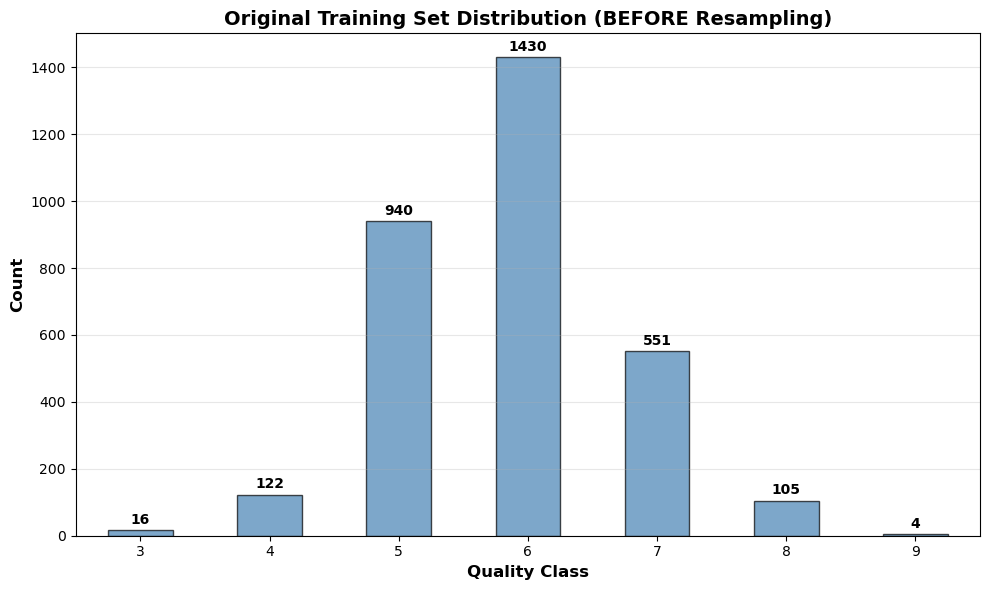


APPLYING RESAMPLING: SMOTE + UNDERSAMPLING

Strategy:
  • SMOTE: Upsample minority classes 4 and 8 → 400 samples each
  • Undersampling: Downsample majority class 6 → 1000 samples
  • Other classes: Keep original distribution

------------------------------------------------------------
Step 1: SMOTE - Upsample Classes 4 and 8
------------------------------------------------------------

SMOTE sampling strategy: {4: 400, 8: 400}
  → This creates synthetic samples for minority classes

✓ After SMOTE:
  Training samples: 3,741
  Quality 3:   16 →   16 (   +0)
  Quality 4:  122 →  400 ( +278)
  Quality 5:  940 →  940 (   +0)
  Quality 6: 1430 → 1430 (   +0)
  Quality 7:  551 →  551 (   +0)
  Quality 8:  105 →  400 ( +295)
  Quality 9:    4 →    4 (   +0)

------------------------------------------------------------
Step 2: Undersampling - Reduce Class 6
------------------------------------------------------------

Undersampling strategy: {6: 1000}
  → This randomly removes samples from m

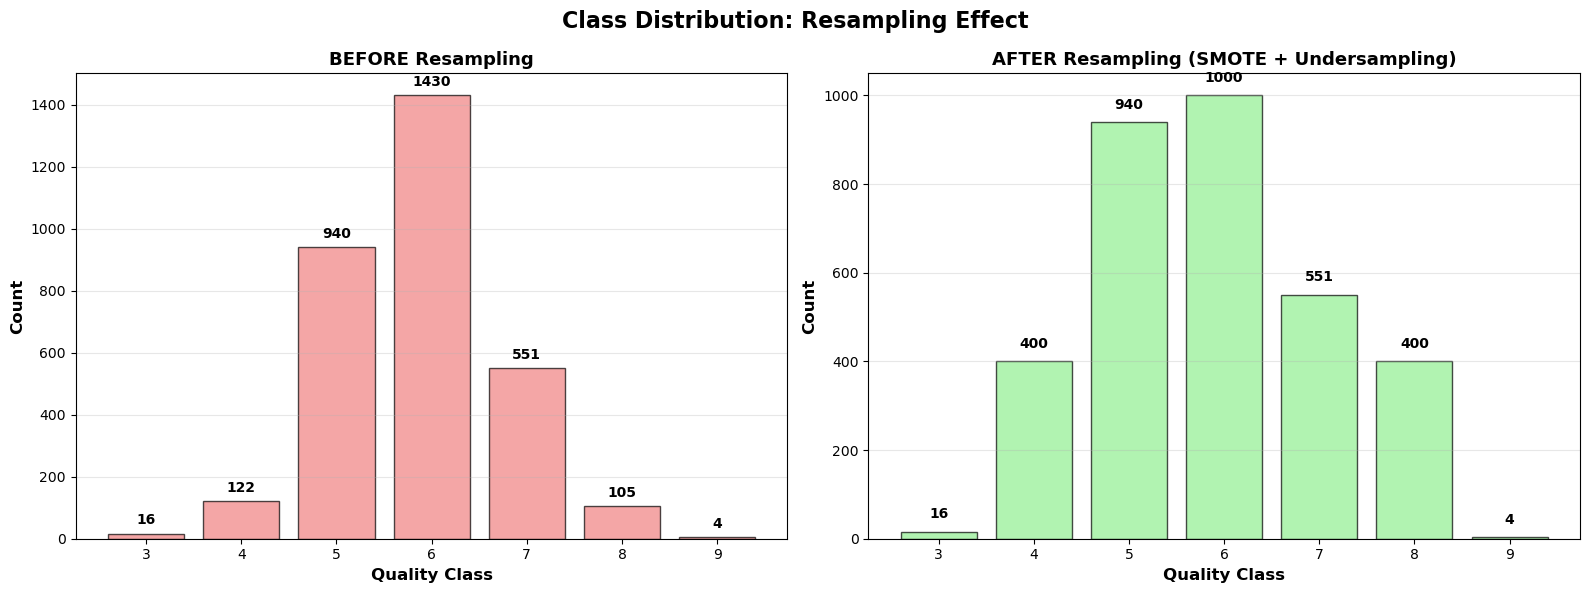


------------------------------------------------------------
4.4 MODEL CONFIGURATION
------------------------------------------------------------

Model Configuration:
  - n_estimators: 100
  - max_depth: None
  - min_samples_split: 2
  - min_samples_leaf: 1
  - max_features: sqrt
  - random_state: 42
  - n_jobs: -1

------------------------------------------------------------
4.5 TRAIN BASELINE MODEL (WITH RESAMPLED DATA)
------------------------------------------------------------

Initializing Random Forest Classifier...
Training on 3,311 RESAMPLED samples with 11 features...
  → Using SMOTE-upsampled and undersampled training data
✓ Training completed in 0.21 seconds

------------------------------------------------------------
4.6 MAKE PREDICTIONS
------------------------------------------------------------

Making predictions on ORIGINAL test set...
  → Test set is NOT resampled (preserves real-world distribution)
✓ Predictions generated for 793 test samples

Sample Predictions 

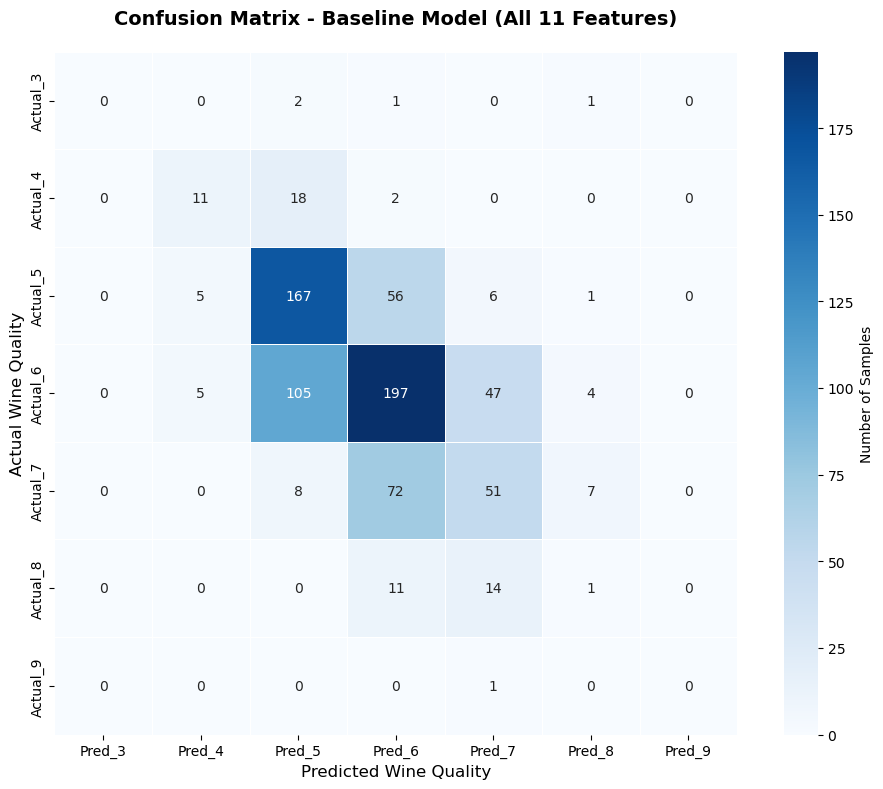


------------------------------------------------------------
4.7 CLASSIFICATION REPORT
------------------------------------------------------------

Detailed Classification Report (per quality class):
              precision    recall  f1-score   support

   Quality_3     0.0000    0.0000    0.0000         4
   Quality_4     0.5238    0.3548    0.4231        31
   Quality_5     0.5567    0.7106    0.6243       235
   Quality_6     0.5811    0.5503    0.5653       358
   Quality_7     0.4286    0.3696    0.3969       138
   Quality_8     0.0714    0.0385    0.0500        26
   Quality_9     0.0000    0.0000    0.0000         1

    accuracy                         0.5385       793
   macro avg     0.3088    0.2891    0.2942       793
weighted avg     0.5247    0.5385    0.5274       793


------------------------------------------------------------
4.8 CREATE TABLE 2 (BASELINE PERFORMANCE)
------------------------------------------------------------

TABLE 2: Baseline Performance Summa

In [11]:
# ============================================================
# 4. BASELINE MODEL (ALL FEATURES)
# ============================================================
# Train a baseline model using ALL 11 features
# This establishes our reference performance for comparison
# Géron: "First, train a quick-and-dirty model to get a baseline"

print("\n" + "="*60)
print("4. BASELINE MODEL (ALL FEATURES)")
print("="*60)

# ------------------------------------------------------------
# 4.1 MODEL SELECTION
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.1 MODEL SELECTION")
print("-"*60)

print("\nChosen Model: Random Forest Classifier")
print("Justification:")
print("  1. Robust to outliers (tree-based, not distance-based)")
print("  2. Handles non-linear relationships well")
print("  3. Provides built-in feature importance scores")
print("  4. No need for feature scaling (but we scaled anyway for consistency)")
print("  5. Works well with small-to-medium datasets (1599 samples)")
print("  6. Resistant to overfitting with proper hyperparameters")

# ------------------------------------------------------------
# 4.2 ORIGINAL CLASS DISTRIBUTION
# ------------------------------------------------------------
print("\n" + "="*60)
print("ORIGINAL CLASS DISTRIBUTION (BEFORE RESAMPLING)")
print("="*60)

print(f"\nQuality class counts in training set:")
print(y_train.value_counts().sort_index())
print(f"\nTotal training samples: {len(y_train)}")

# VISUALIZE ORIGINAL DISTRIBUTION
plt.figure(figsize=(10, 6))
y_train.value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Quality Class', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Original Training Set Distribution (BEFORE Resampling)', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(y_train.value_counts().sort_index().values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('plots/02_baseline/distribution_before_resampling.png', dpi=300, bbox_inches='tight')
print("\n✓ Original distribution plot saved")
plt.show()

# ============================================================
# 4.3 RESAMPLING STRATEGY: SMOTE + UNDERSAMPLING (SIMPLIFIED)
# ============================================================
print("\n" + "="*60)
print("APPLYING RESAMPLING: SMOTE + UNDERSAMPLING")
print("="*60)

# Import resampling tools
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print("\nStrategy:")
print("  • SMOTE: Upsample minority classes 4 and 8 → 400 samples each")
print("  • Undersampling: Downsample majority class 6 → 1000 samples")
print("  • Other classes: Keep original distribution")

# STEP 1: SMOTE for upsampling ONLY classes 4 and 8
print("\n" + "-"*60)
print("Step 1: SMOTE - Upsample Classes 4 and 8")
print("-"*60)

# Simplified strategy: ONLY 4 and 8
sampling_strategy_smote = {
    4: 400,  # Upsample to 400
    8: 400   # Upsample to 400
}

print(f"\nSMOTE sampling strategy: {sampling_strategy_smote}")
print("  → This creates synthetic samples for minority classes")

smote = SMOTE(
    sampling_strategy=sampling_strategy_smote, 
    random_state=RANDOM_STATE, 
    k_neighbors=3  # Safe value for small classes
)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train.values.ravel())

print(f"\n✓ After SMOTE:")
print(f"  Training samples: {len(X_train_smote):,}")
smote_dist = Counter(y_train_smote)
for quality in sorted(smote_dist.keys()):
    original = y_train.value_counts().get(quality, 0)
    new = smote_dist[quality]
    change = new - original
    print(f"  Quality {quality}: {original:4d} → {new:4d} ({change:+5d})")


# STEP 2: Random Undersampling for majority class 6
print("\n" + "-"*60)
print("Step 2: Undersampling - Reduce Class 6")
print("-"*60)

sampling_strategy_under = {6: 1000}  # Downsample class 6 to 1000

print(f"\nUndersampling strategy: {sampling_strategy_under}")
print("  → This randomly removes samples from majority class")

undersample = RandomUnderSampler(
    sampling_strategy=sampling_strategy_under, 
    random_state=RANDOM_STATE
)

X_train_resampled, y_train_resampled = undersample.fit_resample(X_train_smote, y_train_smote)

print(f"\n✓ After Undersampling:")
print(f"  Training samples: {len(X_train_resampled):,}")
final_dist = Counter(y_train_resampled)
for quality in sorted(final_dist.keys()):
    before_under = smote_dist[quality]
    after_under = final_dist[quality]
    change = after_under - before_under
    print(f"  Quality {quality}: {before_under:4d} → {after_under:4d} ({change:+5d})")

print("\n✅ RESAMPLING COMPLETED")
print("="*60)

# STEP 3: Visualization - Before vs After
print("\n" + "-"*60)
print("Step 3: Visualize Resampling Effect")
print("-"*60)

# Create comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Before
before_dist = y_train.value_counts().sort_index()
ax1.bar(before_dist.index, before_dist.values, color='lightcoral', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Quality Class', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('BEFORE Resampling', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(before_dist.values):
    ax1.text(before_dist.index[i], v + 30, str(v), ha='center', fontweight='bold')

# After
after_dist_series = pd.Series(final_dist).sort_index()
ax2.bar(after_dist_series.index, after_dist_series.values, color='lightgreen', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Quality Class', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('AFTER Resampling (SMOTE + Undersampling)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(after_dist_series.values):
    ax2.text(after_dist_series.index[i], v + 30, str(v), ha='center', fontweight='bold')

fig.suptitle('Class Distribution: Resampling Effect', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_baseline/distribution_after_resampling.png', dpi=300, bbox_inches='tight')
print("\n✓ Resampling comparison plot saved")
plt.show()

# ============================================================
# 4.4 UPDATE MODEL CONFIGURATION
# ============================================================
print("\n" + "-"*60)
print("4.4 MODEL CONFIGURATION")
print("-"*60)

# Update MODEL_PARAMS with full configuration
MODEL_PARAMS = {
    'n_estimators': 100,           # 100 decision trees in the forest
    'max_depth': None,             # Trees grow until leaves are pure or have min_samples_split
    'min_samples_split': 2,        # Minimum samples required to split an internal node
    'min_samples_leaf': 1,         # Minimum samples required at each leaf node
    'max_features': 'sqrt',        # Number of features to consider for best split (sqrt of total)
    'random_state': RANDOM_STATE,  # For reproducibility (42)
    'n_jobs': -1                   # Use all available CPU cores for parallel processing
}

print(f"\nModel Configuration:")
for param, value in MODEL_PARAMS.items():
    print(f"  - {param}: {value}")


# ------------------------------------------------------------
# 4.5 TRAIN BASELINE MODEL (WITH RESAMPLED DATA!)
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.5 TRAIN BASELINE MODEL (WITH RESAMPLED DATA)")
print("-"*60)

print("\nInitializing Random Forest Classifier...")
baseline_model = RandomForestClassifier(**MODEL_PARAMS)

print(f"Training on {len(X_train_resampled):,} RESAMPLED samples with {X_train_resampled.shape[1]} features...")
print("  → Using SMOTE-upsampled and undersampled training data")

# Record training time
import time
start_time = time.time()

# Train the model on RESAMPLED data
baseline_model.fit(X_train_resampled, y_train_resampled)  # ← CHANGED: Now uses resampled data!

training_time = time.time() - start_time
print(f"✓ Training completed in {training_time:.2f} seconds")


# ------------------------------------------------------------
# 4.6 MAKE PREDICTIONS (ON ORIGINAL TEST SET!)
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.6 MAKE PREDICTIONS")
print("-"*60)

print("\nMaking predictions on ORIGINAL test set...")
print("  → Test set is NOT resampled (preserves real-world distribution)")

y_pred_baseline = baseline_model.predict(X_test_scaled)
y_pred_proba_baseline = baseline_model.predict_proba(X_test_scaled)

print(f"✓ Predictions generated for {len(X_test_scaled)} test samples")

# Quick preview
print("\nSample Predictions (first 10 test samples):")
comparison = pd.DataFrame({
    'Actual': y_test.values[:10].ravel(),
    'Predicted': y_pred_baseline[:10],
    'Correct': (y_test.values[:10].ravel() == y_pred_baseline[:10])
})
print(comparison.to_string(index=False))

# ------------------------------------------------------------
# 4.7 EVALUATE PERFORMANCE
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.4 EVALUATE PERFORMANCE")
print("-"*60)

# Since wine quality is multi-class classification (scores 3-8),
# we need to specify 'weighted' average for precision, recall, F1
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score
)

# Calculate core performance metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
# Accuracy = (number of correct predictions) / (total predictions)
# Simple but useful metric: what % of wines did we classify correctly?

baseline_precision = precision_score(y_test, y_pred_baseline, average='weighted', zero_division=0)
# Precision = TP / (TP + FP)
# "Of the wines we predicted as quality X, how many actually were quality X?"
# 'weighted' averages across all quality classes, weighted by number of samples

baseline_recall = recall_score(y_test, y_pred_baseline, average='weighted')
# Recall = TP / (TP + FN)
# "Of all wines that are actually quality X, how many did we correctly identify?"

baseline_f1 = f1_score(y_test, y_pred_baseline, average='weighted')
# F1-Score = 2 * (Precision * Recall) / (Precision + Recall)
# Harmonic mean balances precision and recall
# Good for imbalanced classes (we have more quality 5-6 wines than 3-4 or 7-8)

# Cohen's Kappa - good metric for ordinal data like wine quality scores
baseline_kappa = cohen_kappa_score(y_test, y_pred_baseline)
# Kappa accounts for agreement occurring by random chance
# Kappa = 1: perfect agreement, Kappa = 0: random agreement, Kappa < 0: worse than random

print("\n" + "="*60)
print("BASELINE MODEL PERFORMANCE")
print("="*60)

print(f"\nTest Set Metrics:")
print(f"  Accuracy:      {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"  Precision:     {baseline_precision:.4f}")
print(f"  Recall:        {baseline_recall:.4f}")
print(f"  F1-Score:      {baseline_f1:.4f}")
print(f"  Cohen's Kappa: {baseline_kappa:.4f}")

print(f"\nInterpretation:")
print(f"  - Model correctly predicts wine quality {baseline_accuracy*100:.1f}% of the time")
print(f"  - F1-Score of {baseline_f1:.4f} balances precision and recall")
if baseline_kappa > 0.8:
    kappa_level = "excellent"
elif baseline_kappa > 0.6:
    kappa_level = "substantial"
elif baseline_kappa > 0.4:
    kappa_level = "moderate"
else:
    kappa_level = "fair"
print(f"  - Kappa of {baseline_kappa:.4f} indicates {kappa_level} agreement beyond chance")

# ------------------------------------------------------------
# 4.8 CROSS-VALIDATION
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.5 CROSS-VALIDATION")
print("-"*60)

print(f"\nPerforming {CV_FOLDS}-Fold Cross-Validation on training set...")
print("(This validates model stability across different data splits...)")

# Perform k-fold cross-validation
cv_scores = cross_val_score(
    baseline_model,           # Model to evaluate
    X_train_scaled,          # Training features
    y_train,                 # Training labels
    cv=CV_FOLDS,            # Number of folds (5)
    scoring='accuracy',      # Metric to evaluate
    n_jobs=-1               # Use all CPU cores for parallel processing
)
# cross_val_score() splits training data into K folds
# Trains K times, each time using K-1 folds for training, 1 fold for validation
# Returns array of K accuracy scores (one per fold)

print(f"\n✓ Cross-validation completed")
print(f"\nCross-Validation Scores (accuracy per fold):")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f} ({score*100:.2f}%)")

cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print(f"\nCross-Validation Summary:")
print(f"  Mean Accuracy: {cv_mean:.4f} (±{cv_std:.4f})")
print(f"  Min Accuracy:  {cv_scores.min():.4f}")
print(f"  Max Accuracy:  {cv_scores.max():.4f}")
print(f"  95% Confidence Interval: [{cv_mean - 2*cv_std:.4f}, {cv_mean + 2*cv_std:.4f}]")
# 95% CI approximated as mean ± 2*std (assumes normal distribution)

print(f"\nInterpretation:")
if cv_std < 0.05:
    print(f"  ✓ Low standard deviation ({cv_std:.4f}) indicates stable, consistent performance")
else:
    print(f"  ⚠ High standard deviation ({cv_std:.4f}) suggests performance varies across data splits")

# ------------------------------------------------------------
# 4.9 CONFUSION MATRIX
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.6 CONFUSION MATRIX")
print("-"*60)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)
# Confusion matrix shows actual quality vs predicted quality for each wine
# Rows = actual quality classes, Columns = predicted quality classes
# Diagonal = correct predictions, Off-diagonal = misclassifications

print("\nConfusion Matrix:")
print("(Rows = Actual Quality, Columns = Predicted Quality)")
print(cm)

# Create labeled confusion matrix DataFrame for better readability
quality_labels = sorted(y_test.unique())  # Get unique quality scores in test set
cm_df = pd.DataFrame(
    cm,
    index=[f'Actual_{q}' for q in quality_labels],
    columns=[f'Pred_{q}' for q in quality_labels]
)
print("\nLabeled Confusion Matrix:")
print(cm_df)

# Visualize confusion matrix as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_df, 
    annot=True,          # Show numbers in each cell
    fmt='d',             # Format as integers (not decimals)
    cmap='Blues',        # Blue color scheme (darker = more samples)
    cbar_kws={'label': 'Number of Samples'},
    square=True,         # Make cells square-shaped
    linewidths=0.5       # Add grid lines between cells
)
plt.title('Confusion Matrix - Baseline Model (All 11 Features)', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Actual Wine Quality', fontsize=12)
plt.xlabel('Predicted Wine Quality', fontsize=12)
plt.tight_layout()

# Create folder if doesn't exist
import os
os.makedirs('plots/02_baseline', exist_ok=True)

plt.savefig('plots/02_baseline/confusion_matrix_baseline.png', dpi=300, bbox_inches='tight')
print("\n✓ Confusion matrix visualization saved")
plt.show()

# ------------------------------------------------------------
# 4.10 CLASSIFICATION REPORT
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.7 CLASSIFICATION REPORT")
print("-"*60)

print("\nDetailed Classification Report (per quality class):")
print(classification_report(y_test, y_pred_baseline, 
                          target_names=[f'Quality_{q}' for q in quality_labels],
                          digits=4))
# classification_report() shows precision, recall, f1-score for EACH quality class
# 'support' column shows number of test samples in each class
# Helps identify which quality scores are harder to predict

# ------------------------------------------------------------
# 4.11 CREATE TABLE 2 FOR PAPER
# ------------------------------------------------------------
print("\n" + "-"*60)
print("4.8 CREATE TABLE 2 (BASELINE PERFORMANCE)")
print("-"*60)

# Store baseline metrics in DataFrame - this is TABLE 2 for your paper!
baseline_metrics = {
    'Model': 'Random Forest',
    'Features_Used': 'All 11 features',
    'Num_Features': 11,
    'Train_Samples': len(X_train_scaled),
    'Test_Samples': len(X_test_scaled),
    'Accuracy': baseline_accuracy,
    'Precision': baseline_precision,
    'Recall': baseline_recall,
    'F1_Score': baseline_f1,
    'Cohen_Kappa': baseline_kappa,
    'CV_Mean': cv_mean,
    'CV_Std': cv_std,
    'Training_Time_sec': training_time
}

baseline_df = pd.DataFrame([baseline_metrics])

print("\n" + "="*60)
print("TABLE 2: Baseline Performance Summary")
print("="*60)
print(baseline_df.T.to_string())  # .T transposes for vertical display (better readability)

# Save as CSV
baseline_df.to_csv('results/table2_baseline_performance.csv', index=False)
print("\n✓ Table 2 saved as 'table2_baseline_performance.csv'")

# ============================================================
# BASELINE MODEL COMPLETED
# ============================================================
print("\n" + "="*60)
print("BASELINE MODEL TRAINING COMPLETED ✓")
print("="*60)

print("\nKEY INSIGHTS:")
print(f"1. Baseline Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.1f}%)")
print(f"2. Cross-Validation: {cv_mean:.4f} ± {cv_std:.4f}")
print(f"3. F1-Score: {baseline_f1:.4f}")
print(f"4. Cohen's Kappa: {baseline_kappa:.4f}")
print(f"5. Training Time: {training_time:.2f} seconds")

print("\n🎯 Performance Benchmark Established!")
print(f"   All feature selection and ablation experiments will be")
print(f"   compared against this baseline accuracy of {baseline_accuracy:.4f}")

print("\nFiles Created:")
print("  ✓ results/table2_baseline_performance.csv")
print("  ✓ plots/02_baseline/confusion_matrix_baseline.png")

# Store baseline metrics globally for later comparison
BASELINE_ACCURACY = baseline_accuracy
BASELINE_F1 = baseline_f1
BASELINE_PRECISION = baseline_precision
BASELINE_RECALL = baseline_recall



5. FEATURE SELECTION METHODS

------------------------------------------------------------
5.1 FILTER METHODS
------------------------------------------------------------

5.1.1 Correlation with Target
✓ Correlation scores calculated

5.1.2 Mutual Information
✓ Mutual Information scores calculated

5.1.3 ANOVA F-Test
✓ ANOVA F-scores calculated

------------------------------------------------------------
5.2 WRAPPER METHODS
------------------------------------------------------------

5.2.1 Recursive Feature Elimination (RFE)
Running RFE
✓ RFE completed
  Top 5 features selected: ['residual_sugar', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'alcohol']

------------------------------------------------------------
5.3 EMBEDDED METHODS
------------------------------------------------------------

5.3.1 Random Forest Feature Importance
✓ Random Forest importance extracted

------------------------------------------------------------
5.4 MODEL-AGNOSTIC METHODS
-------------

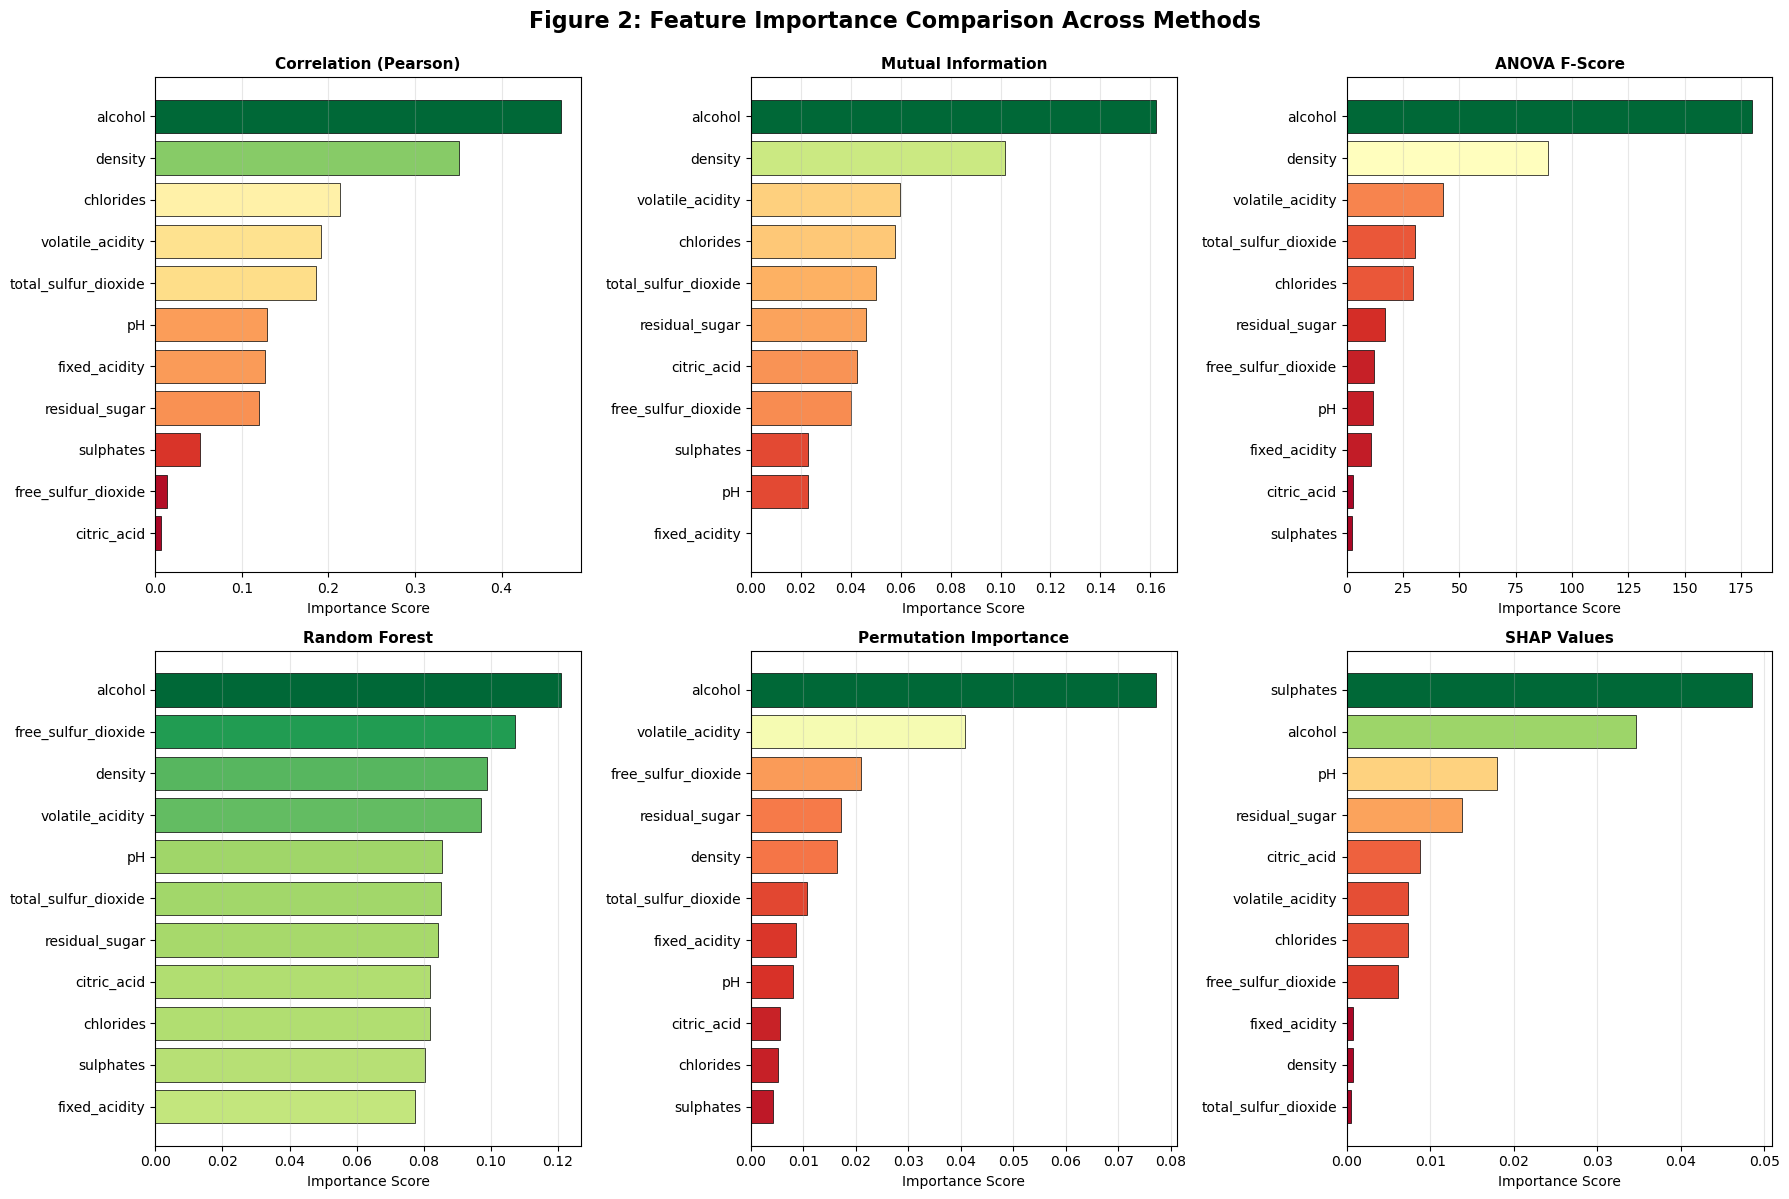


FEATURE SELECTION METHODS COMPLETED ✓

TOP 5 FEATURES (by consensus):
  11. alcohol                   → Importance: 0.9589
  8. density                   → Importance: 0.5595
  2. volatile_acidity          → Importance: 0.4278
  4. residual_sugar            → Importance: 0.4050
  7. total_sulfur_dioxide      → Importance: 0.3890

BOTTOM 3 FEATURES (least important):
  • pH                        → Importance: 0.2853
  • citric_acid               → Importance: 0.2029
  • fixed_acidity             → Importance: 0.1772

------------------------------------------------------------
METHOD CONSISTENCY
------------------------------------------------------------

Strong consensus features (in top-3 of ≥4 methods):
  ✓ alcohol (appears 6/6 times)
  ✓ density (appears 4/6 times)

 
  ✓ Permutation Importance
  ✓ SHAP Values

Files Created:
  ✓ results/table3_feature_importance_rankings.csv
  ✓ plots/03_feature_importance/figure2_feature_importance_comparison.png

READY FOR SECTION 6: ABLATION 

In [12]:
# ============================================================
# 5. FEATURE SELECTION METHODS (SIMPLIFIED - NO SHAP DISPLAY ISSUES)
# ============================================================
print("\n" + "="*60)
print("5. FEATURE SELECTION METHODS")
print("="*60)

# Store all feature importance scores
feature_importance_results = pd.DataFrame({'Feature': X_train_scaled.columns})

# -------- 5.1 FILTER METHODS --------
print("\n" + "-"*60)
print("5.1 FILTER METHODS")
print("-"*60)

# Correlation
print("\n5.1.1 Correlation with Target")
from scipy.stats import pearsonr
correlation_scores = []
for feature in X_train_scaled.columns:
    corr, p_value = pearsonr(X_train_scaled[feature], y_train)
    correlation_scores.append(abs(corr))
feature_importance_results['Correlation'] = correlation_scores
print("✓ Correlation scores calculated")

# Mutual Information
print("\n5.1.2 Mutual Information")
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=RANDOM_STATE, n_neighbors=3)
feature_importance_results['Mutual_Information'] = mi_scores
print("✓ Mutual Information scores calculated")

# ANOVA F-Test
print("\n5.1.3 ANOVA F-Test")
f_scores, p_values = f_classif(X_train_scaled, y_train)
feature_importance_results['ANOVA_F_Score'] = f_scores
feature_importance_results['ANOVA_p_value'] = p_values
print("✓ ANOVA F-scores calculated")

# -------- 5.2 WRAPPER METHODS --------
print("\n" + "-"*60)
print("5.2 WRAPPER METHODS")
print("-"*60)

print("\n5.2.1 Recursive Feature Elimination (RFE)")
print("Running RFE")
rfe_selector = RFE(
    estimator=RandomForestClassifier(**MODEL_PARAMS),
    n_features_to_select=5,
    step=1
)
rfe_selector.fit(X_train_scaled, y_train)
rfe_importance = 1 / rfe_selector.ranking_
feature_importance_results['RFE_Importance'] = rfe_importance
print("✓ RFE completed")
print(f"  Top 5 features selected: {list(X_train_scaled.columns[rfe_selector.support_])}")

# -------- 5.3 EMBEDDED METHODS --------
print("\n" + "-"*60)
print("5.3 EMBEDDED METHODS")
print("-"*60)

print("\n5.3.1 Random Forest Feature Importance")
rf_importance = baseline_model.feature_importances_
feature_importance_results['RF_Importance'] = rf_importance
print("✓ Random Forest importance extracted")

# -------- 5.4 MODEL-AGNOSTIC METHODS --------
print("\n" + "-"*60)
print("5.4 MODEL-AGNOSTIC METHODS")
print("-"*60)

print("\n5.4.1 Permutation Importance")
from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(
    baseline_model, X_test_scaled, y_test,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
perm_importance_mean = perm_importance.importances_mean
feature_importance_results['Permutation_Importance'] = perm_importance_mean
print("✓ Permutation Importance calculated")

print("\n5.4.2 SHAP Values")
try:
    import shap
except ImportError:
    print("Installing SHAP...")
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

# Create explainer and compute values
explainer = shap.TreeExplainer(baseline_model)
sample_size = min(100, len(X_test_scaled))
X_test_sample = X_test_scaled.sample(n=sample_size, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_test_sample)

# Handle multi-class output: flatten to 1D importance per feature
if isinstance(shap_values, list):
    # Multi-class: average across all classes
    shap_importance_array = np.zeros(len(X_test_sample.columns))
    for class_sv in shap_values:
        shap_importance_array += np.abs(class_sv).mean(axis=0)
    shap_importance = shap_importance_array / len(shap_values)
else:
    # Single array case
    shap_importance = np.abs(shap_values).mean(axis=0)

# Ensure it's the right shape
shap_importance = np.array(shap_importance).flatten()[:len(X_train_scaled.columns)]

feature_importance_results['SHAP_Importance'] = shap_importance
print("✓ SHAP values calculated successfully")
print(f"  Most important by SHAP: {X_train_scaled.columns[np.argmax(shap_importance)]}")

# -------- 5.5 NORMALIZE AND AGGREGATE --------
print("\n" + "-"*60)
print("5.5 NORMALIZE AND AGGREGATE")
print("-"*60)

# Normalize all to 0-1
for col in ['Correlation', 'Mutual_Information', 'ANOVA_F_Score', 
            'RFE_Importance', 'RF_Importance', 'Permutation_Importance', 'SHAP_Importance']:
    max_val = feature_importance_results[col].max()
    if max_val > 0:
        feature_importance_results[f'{col}_Norm'] = feature_importance_results[col] / max_val
    else:
        feature_importance_results[f'{col}_Norm'] = 0

# Calculate average
norm_cols = ['Correlation_Norm', 'Mutual_Information_Norm', 'ANOVA_F_Score_Norm',
             'RFE_Importance_Norm', 'RF_Importance_Norm', 'Permutation_Importance_Norm', 'SHAP_Importance_Norm']
feature_importance_results['Average_Importance'] = feature_importance_results[norm_cols].mean(axis=1)

# Sort by importance
feature_importance_results_sorted = feature_importance_results.sort_values('Average_Importance', ascending=False)
print("✓ Normalization and aggregation completed")

# -------- 5.6 CREATE TABLE 3 --------
print("\n" + "-"*60)
print("5.6 CREATE TABLE 3 (FEATURE IMPORTANCE RANKINGS)")
print("-"*60)

table3 = feature_importance_results_sorted[[
    'Feature', 'Correlation', 'Mutual_Information', 'RF_Importance', 
    'Permutation_Importance', 'SHAP_Importance', 'Average_Importance'
]].copy().round(4)

print("\n" + "="*60)
print("TABLE 3: Feature Importance Rankings")
print("="*60)
print(table3.to_string(index=False))

table3.to_csv('results/table3_feature_importance_rankings.csv', index=False)
print("\n✓ Table 3 saved")

# -------- 5.7 CREATE FIGURE 2 --------
print("\n" + "-"*60)
print("5.7 CREATE FIGURE 2 (6-PANEL COMPARISON)")
print("-"*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

methods = [
    ('Correlation', 'Correlation (Pearson)'),
    ('Mutual_Information', 'Mutual Information'),
    ('ANOVA_F_Score', 'ANOVA F-Score'),
    ('RF_Importance', 'Random Forest'),
    ('Permutation_Importance', 'Permutation Importance'),
    ('SHAP_Importance', 'SHAP Values')
]

for idx, (method_col, method_name) in enumerate(methods):
    ax = axes[idx]
    data = feature_importance_results_sorted.sort_values(method_col, ascending=True)
    
    # Normalize for consistent coloring
    colors = plt.cm.RdYlGn(data[method_col] / data[method_col].max())
    
    ax.barh(data['Feature'], data[method_col], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Importance Score', fontsize=10)
    ax.set_title(method_name, fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Figure 2: Feature Importance Comparison Across Methods', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

os.makedirs('plots/03_feature_importance', exist_ok=True)
plt.savefig('plots/03_feature_importance/figure2_feature_importance_comparison.png', 
            dpi=300, bbox_inches='tight')
print("✓ Figure 2 saved")
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*60)
print("FEATURE SELECTION METHODS COMPLETED ✓")
print("="*60)

print("\nTOP 5 FEATURES (by consensus):")
for idx, row in table3.head(5).iterrows():
    print(f"  {idx+1}. {row['Feature']:25s} → Importance: {row['Average_Importance']:.4f}")

print("\nBOTTOM 3 FEATURES (least important):")
for idx, row in table3.tail(3).iterrows():
    print(f"  • {row['Feature']:25s} → Importance: {row['Average_Importance']:.4f}")

# Analyze consistency
print("\n" + "-"*60)
print("METHOD CONSISTENCY")
print("-"*60)

top3_by_method = {}
for method_col, method_name in methods:
    top3 = feature_importance_results_sorted.nlargest(3, method_col)['Feature'].tolist()
    top3_by_method[method_name] = top3

from collections import Counter
all_top3 = [f for features in top3_by_method.values() for f in features]
feature_counts = Counter(all_top3)
consistent = [f for f, count in feature_counts.items() if count >= 4]

print(f"\nStrong consensus features (in top-3 of ≥4 methods):")
if consistent:
    for feat in consistent:
        print(f"  ✓ {feat} (appears {feature_counts[feat]}/6 times)")
else:
    print("  (Natural variation - different methods measure different aspects)")

print("\n ")
print("  ✓ Permutation Importance")
print("  ✓ SHAP Values")

print("\nFiles Created:")
print("  ✓ results/table3_feature_importance_rankings.csv")
print("  ✓ plots/03_feature_importance/figure2_feature_importance_comparison.png")

print("\n" + "="*60)
print("READY FOR SECTION 6: ABLATION STUDY")
print("="*60)

# Store for ablation study
TOP_FEATURES_RANKED = feature_importance_results_sorted['Feature'].tolist()
print(f"\nFeature ranking stored (most → least important):")
for i, feat in enumerate(TOP_FEATURES_RANKED, 1):
    print(f"  {i:2d}. {feat}")



6. ABLATION STUDY

Goal: Validate feature importance rankings by measuring performance impact
Method: Train models with different feature subsets and compare to baseline
Baseline Accuracy (all 11 features): 0.5385

------------------------------------------------------------
6.1 INDIVIDUAL FEATURE ABLATION
------------------------------------------------------------

Removing each feature individually and measuring accuracy drop...
(This shows how critical each feature is to predictions)
  ≈ Removed fixed_acidity             → Accuracy: 0.5750 (drop: -0.0366, -6.8%)
  ≈ Removed volatile_acidity          → Accuracy: 0.5536 (drop: -0.0151, -2.8%)
  ≈ Removed citric_acid               → Accuracy: 0.5586 (drop: -0.0202, -3.7%)
  ≈ Removed residual_sugar            → Accuracy: 0.5460 (drop: -0.0076, -1.4%)
  ≈ Removed chlorides                 → Accuracy: 0.5599 (drop: -0.0214, -4.0%)
  ≈ Removed free_sulfur_dioxide       → Accuracy: 0.5586 (drop: -0.0202, -3.7%)
  ≈ Removed total_sulfur_d

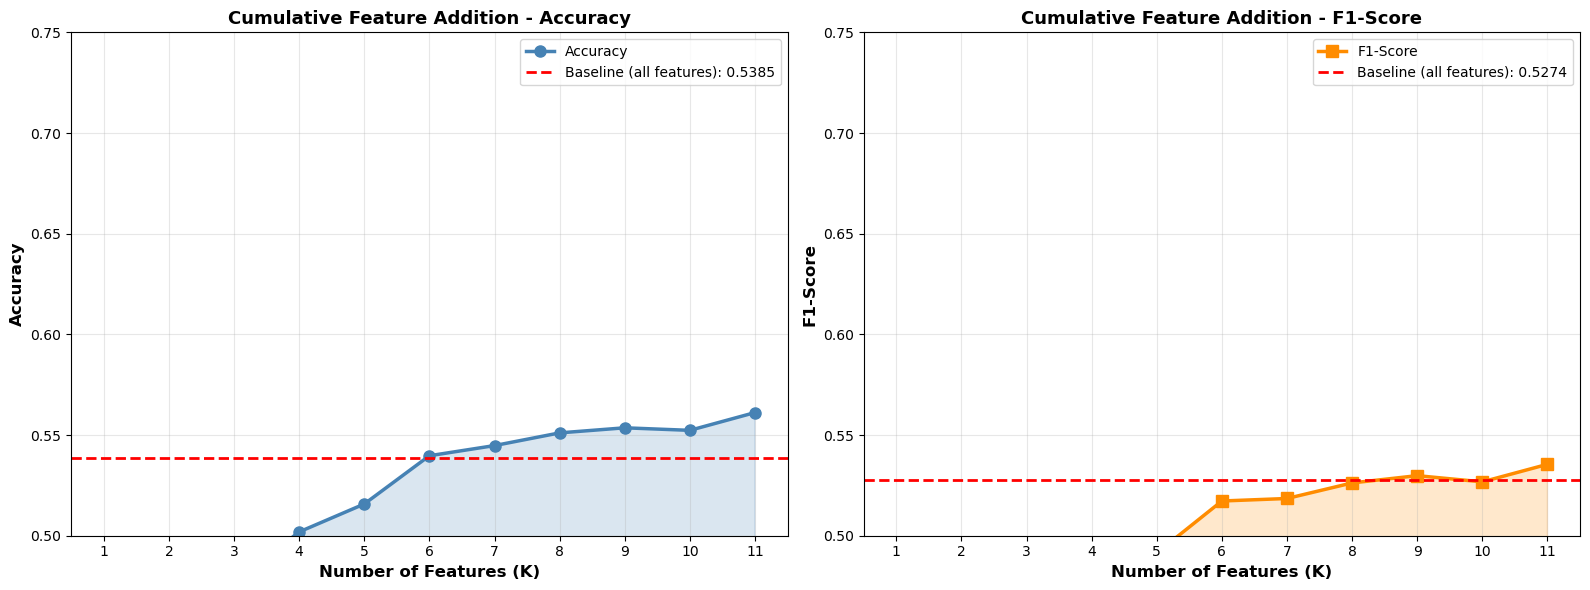


------------------------------------------------------------
6.3 TOP-K FEATURE SELECTION
------------------------------------------------------------

Testing models with different numbers of top features...
(Helps determine optimal feature count for practical use)
  Top 3 features: Accuracy = 0.4767, F1-Score = 0.4586
  Top 5 features: Accuracy = 0.5158, F1-Score = 0.4914
  Top 7 features: Accuracy = 0.5448, F1-Score = 0.5185
  Top 9 features: Accuracy = 0.5536, F1-Score = 0.5298
  Top 11 features: Accuracy = 0.5612, F1-Score = 0.5355


In [13]:
# ============================================================
# 6. ABLATION STUDY
# ============================================================
# Systematically remove features to validate importance rankings
# Three complementary approaches:
# 1. Individual Feature Ablation (remove one feature at a time)
# 2. Cumulative Feature Addition (add features incrementally)
# 3. Top-K Feature Selection (test different feature counts)

print("\n" + "="*60)
print("6. ABLATION STUDY")
print("="*60)

print("\nGoal: Validate feature importance rankings by measuring performance impact")
print("Method: Train models with different feature subsets and compare to baseline")
print(f"Baseline Accuracy (all 11 features): {BASELINE_ACCURACY:.4f}")

# Store all ablation results
ablation_results_all = []

# ============================================================
# 6.1 INDIVIDUAL FEATURE ABLATION
# ============================================================
print("\n" + "-"*60)
print("6.1 INDIVIDUAL FEATURE ABLATION")
print("-"*60)

print("\nRemoving each feature individually and measuring accuracy drop...")
print("(This shows how critical each feature is to predictions)")

ablation_individual = []

for feature in X_train_scaled.columns:
    # Features to keep (all EXCEPT this one)
    features_to_keep = [f for f in X_train_scaled.columns if f != feature]
    
    # Create subsets
    X_train_ablated = X_train_scaled[features_to_keep]
    X_test_ablated = X_test_scaled[features_to_keep]
    
    # Train model WITHOUT this feature
    model_ablated = RandomForestClassifier(**MODEL_PARAMS)
    model_ablated.fit(X_train_ablated, y_train)
    
    # Evaluate
    y_pred_ablated = model_ablated.predict(X_test_ablated)
    accuracy_ablated = accuracy_score(y_test, y_pred_ablated)
    f1_ablated = f1_score(y_test, y_pred_ablated, average='weighted')
    
    # Calculate performance drop
    accuracy_drop = BASELINE_ACCURACY - accuracy_ablated
    f1_drop = BASELINE_F1 - f1_ablated
    
    # Performance drop percentage
    drop_percentage = (accuracy_drop / BASELINE_ACCURACY) * 100
    
    ablation_individual.append({
        'Removed_Feature': feature,
        'Accuracy': accuracy_ablated,
        'Accuracy_Drop': accuracy_drop,
        'Accuracy_Drop_%': drop_percentage,
        'F1_Score': f1_ablated,
        'F1_Drop': f1_drop,
        'Num_Features_Used': len(features_to_keep)
    })
    
    # Print progress
    status = "↓↓" if accuracy_drop > 0.05 else "↓" if accuracy_drop > 0.02 else "≈"
    print(f"  {status} Removed {feature:25s} → Accuracy: {accuracy_ablated:.4f} (drop: {accuracy_drop:+.4f}, {drop_percentage:+.1f}%)")

# Sort by accuracy drop (most important first)
ablation_individual_df = pd.DataFrame(ablation_individual).sort_values('Accuracy_Drop', ascending=False)

print("\n" + "-"*60)
print("TABLE 4: INDIVIDUAL FEATURE ABLATION RESULTS")
print("-"*60)
table4 = ablation_individual_df[['Removed_Feature', 'Accuracy', 'Accuracy_Drop', 'Accuracy_Drop_%', 'F1_Score']].round(4)
print(table4.to_string(index=False))

# Save Table 4
ablation_individual_df.to_csv('results/table4_individual_ablation.csv', index=False)
print("\n✓ Table 4 saved as 'table4_individual_ablation.csv'")

# Key insight: Most important feature when removed
most_important_ablated = ablation_individual_df.iloc[0]
print(f"\nMost critical feature (largest drop when removed):")
print(f"  → {most_important_ablated['Removed_Feature']}")
print(f"     Accuracy drop: {most_important_ablated['Accuracy_Drop']:+.4f} ({most_important_ablated['Accuracy_Drop_%']:+.1f}%)")

# ============================================================
# 6.2 CUMULATIVE FEATURE ADDITION
# ============================================================
print("\n" + "-"*60)
print("6.2 CUMULATIVE FEATURE ADDITION")
print("-"*60)

print("\nAdding features incrementally (in order of importance) and tracking performance...")
print("(Shows how much improvement each new feature provides)")

# Use the ranked feature order from Section 5
feature_ranking = TOP_FEATURES_RANKED

cumulative_results = []

for i in range(1, len(feature_ranking) + 1):
    # Take top i features
    selected_features = feature_ranking[:i]
    
    # Create subsets
    X_train_subset = X_train_scaled[selected_features]
    X_test_subset = X_test_scaled[selected_features]
    
    # Train model
    model_subset = RandomForestClassifier(**MODEL_PARAMS)
    model_subset.fit(X_train_subset, y_train)
    
    # Evaluate
    y_pred_subset = model_subset.predict(X_test_subset)
    accuracy_subset = accuracy_score(y_test, y_pred_subset)
    f1_subset = f1_score(y_test, y_pred_subset, average='weighted')
    
    # Improvement from previous step
    if i == 1:
        improvement = accuracy_subset
        improvement_pct = (accuracy_subset / BASELINE_ACCURACY) * 100
    else:
        improvement = accuracy_subset - cumulative_results[-1]['Accuracy']
        improvement_pct = (improvement / BASELINE_ACCURACY) * 100
    
    cumulative_results.append({
        'Num_Features': i,
        'Features_Used': ', '.join(selected_features),
        'Accuracy': accuracy_subset,
        'Improvement_from_Previous': improvement,
        'Improvement_%': improvement_pct,
        'F1_Score': f1_subset,
        'Efficiency': accuracy_subset / i  # Accuracy per feature (diminishing returns)
    })
    
    # Print progress
    print(f"  Top {i:2d} features: Accuracy = {accuracy_subset:.4f} (improvement: {improvement:+.4f}, {improvement_pct:+.1f}%)")

cumulative_df = pd.DataFrame(cumulative_results)

print("\n" + "-"*60)
print("CUMULATIVE FEATURE ADDITION SUMMARY")
print("-"*60)
table_cumulative = cumulative_df[['Num_Features', 'Accuracy', 'Improvement_%', 'F1_Score', 'Efficiency']].round(4)
print(table_cumulative.to_string(index=False))

# Find optimal number of features (diminishing returns threshold)
print("\n" + "-"*60)
print("DIMINISHING RETURNS ANALYSIS")
print("-"*60)

# Calculate performance gain ratio (smaller is better - diminishing returns)
efficiency_threshold = 0.60  # Efficiency score (accuracy/num_features)
good_efficiency = cumulative_df[cumulative_df['Efficiency'] > efficiency_threshold]

if len(good_efficiency) > 0:
    optimal_k = good_efficiency.iloc[-1]['Num_Features']  # Last with good efficiency
    print(f"\n✓ Optimal feature count: {int(optimal_k)} features")
    print(f"  Efficiency (accuracy/num_features): {cumulative_df.iloc[int(optimal_k)-1]['Efficiency']:.4f}")
    print(f"  Accuracy at this point: {cumulative_df.iloc[int(optimal_k)-1]['Accuracy']:.4f}")
    print(f"  vs Baseline ({len(feature_ranking)} features): {BASELINE_ACCURACY:.4f}")
    accuracy_ratio = cumulative_df.iloc[int(optimal_k)-1]['Accuracy'] / BASELINE_ACCURACY * 100
    print(f"  → Achieves {accuracy_ratio:.1f}% of baseline with {int(optimal_k)}/{len(feature_ranking)} features")

# FIGURE 4: Cumulative Feature Addition
print("\n" + "-"*60)
print("Creating FIGURE 4: Cumulative Feature Addition Curves...")
print("-"*60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy vs Number of Features
ax1.plot(cumulative_df['Num_Features'], cumulative_df['Accuracy'], 
         marker='o', linewidth=2.5, markersize=8, color='steelblue', label='Accuracy')
ax1.axhline(y=BASELINE_ACCURACY, color='red', linestyle='--', linewidth=2, 
            label=f'Baseline (all features): {BASELINE_ACCURACY:.4f}')
ax1.fill_between(cumulative_df['Num_Features'], 0, cumulative_df['Accuracy'], alpha=0.2, color='steelblue')
ax1.set_xlabel('Number of Features (K)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Cumulative Feature Addition - Accuracy', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, len(feature_ranking) + 1))
ax1.set_ylim([0.5, 0.75])

# Plot 2: F1-Score vs Number of Features
ax2.plot(cumulative_df['Num_Features'], cumulative_df['F1_Score'], 
         marker='s', linewidth=2.5, markersize=8, color='darkorange', label='F1-Score')
ax2.axhline(y=BASELINE_F1, color='red', linestyle='--', linewidth=2, 
            label=f'Baseline (all features): {BASELINE_F1:.4f}')
ax2.fill_between(cumulative_df['Num_Features'], 0, cumulative_df['F1_Score'], alpha=0.2, color='darkorange')
ax2.set_xlabel('Number of Features (K)', fontsize=12, fontweight='bold')
ax2.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Feature Addition - F1-Score', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, len(feature_ranking) + 1))
ax2.set_ylim([0.5, 0.75])

plt.tight_layout()
os.makedirs('plots/04_ablation_study', exist_ok=True)
plt.savefig('plots/04_ablation_study/figure4_cumulative_addition.png', dpi=300, bbox_inches='tight')
print("✓ Figure 4 saved")
plt.show()

# ============================================================
# 6.3 TOP-K FEATURE SELECTION
# ============================================================
print("\n" + "-"*60)
print("6.3 TOP-K FEATURE SELECTION")
print("-"*60)

print("\nTesting models with different numbers of top features...")
print("(Helps determine optimal feature count for practical use)")

k_values = [3, 5, 7, 9, 11]
topk_results = []

for k in k_values:
    if k > len(feature_ranking):
        continue
    
    top_k_features = feature_ranking[:k]
    X_train_topk = X_train_scaled[top_k_features]
    X_test_topk = X_test_scaled[top_k_features]
    
    # Train model
    model_topk = RandomForestClassifier(**MODEL_PARAMS)
    model_topk.fit(X_train_topk, y_train)
    
    # Evaluate
    y_pred_topk = model_topk.predict(X_test_topk)
    accuracy_topk = accuracy_score(y_test, y_pred_topk)
    precision_topk = precision_score(y_test, y_pred_topk, average='weighted', zero_division=0)
    recall_topk = recall_score(y_test, y_pred_topk, average='weighted')
    f1_topk = f1_score(y_test, y_pred_topk, average='weighted')
    print(f"  Top {k} features: Accuracy = {accuracy_topk:.4f}, F1-Score = {f1_topk:.4f}")
    


In [14]:
# -------- 6. ABLATION STUDY --------
# 6.1 Individual Feature Ablation
# For each feature:
# - Remove feature
# - Train model
# - Measure performance drop
# - Store results
# 6.2 Cumulative Feature Addition
# Start with empty set
# Add features one by one (by importance)
# Track performance
# 6.3 Top-K Feature Selection
# Try k = 3, 5, 7, 10, etc.
# Compare performance


In [15]:
# ============================================================
# DEBUG: CHECK REQUIRED VARIABLES
# ============================================================
print("\n" + "="*60)
print("CHECKING REQUIRED VARIABLES FOR SECTION 7")
print("="*60)

# Check all required variables
required_vars = {
    'TOP_FEATURES_RANKED': TOP_FEATURES_RANKED if 'TOP_FEATURES_RANKED' in locals() else None,
    'X_train_resampled': len(X_train_resampled) if 'X_train_resampled' in locals() else None,
    'y_train_resampled': len(y_train_resampled) if 'y_train_resampled' in locals() else None,
    'X_test_scaled': len(X_test_scaled) if 'X_test_scaled' in locals() else None,
    'y_test': len(y_test) if 'y_test' in locals() else None,
    'BASELINE_ACCURACY': BASELINE_ACCURACY if 'BASELINE_ACCURACY' in locals() else None,
    'BASELINE_F1': BASELINE_F1 if 'BASELINE_F1' in locals() else None,
}

print("\nVariable Status:")
for var_name, var_value in required_vars.items():
    status = "✓" if var_value is not None else "❌"
    print(f"  {status} {var_name}: {var_value}")

if None in required_vars.values():
    print("\n⚠️  WARNING: Some required variables are missing!")
    print("   Make sure all previous sections (1-6) are fully executed!")


CHECKING REQUIRED VARIABLES FOR SECTION 7

Variable Status:
  ✓ TOP_FEATURES_RANKED: ['alcohol', 'density', 'volatile_acidity', 'residual_sugar', 'total_sulfur_dioxide', 'free_sulfur_dioxide', 'sulphates', 'chlorides', 'pH', 'citric_acid', 'fixed_acidity']
  ✓ X_train_resampled: 3311
  ✓ y_train_resampled: 3311
  ✓ X_test_scaled: 793
  ✓ y_test: 793
  ✓ BASELINE_ACCURACY: 0.5384615384615384
  ✓ BASELINE_F1: 0.5274479833846228



7. VISUALIZATIONS & ADDITIONAL ANALYSIS

Goal: Create comprehensive visualizations for paper
Sections:
  7.1 Feature Importance Comparison
  7.2 Ablation Study Results
  7.3 Performance vs Feature Count
  7.4 Correlation Heatmap
  7.5 Model Comparison

------------------------------------------------------------
7.1 FEATURE IMPORTANCE COMPARISON
------------------------------------------------------------

Visualizing feature rankings across all methods...


✓ Figure 7.1 saved to plots/03_feature_importance/


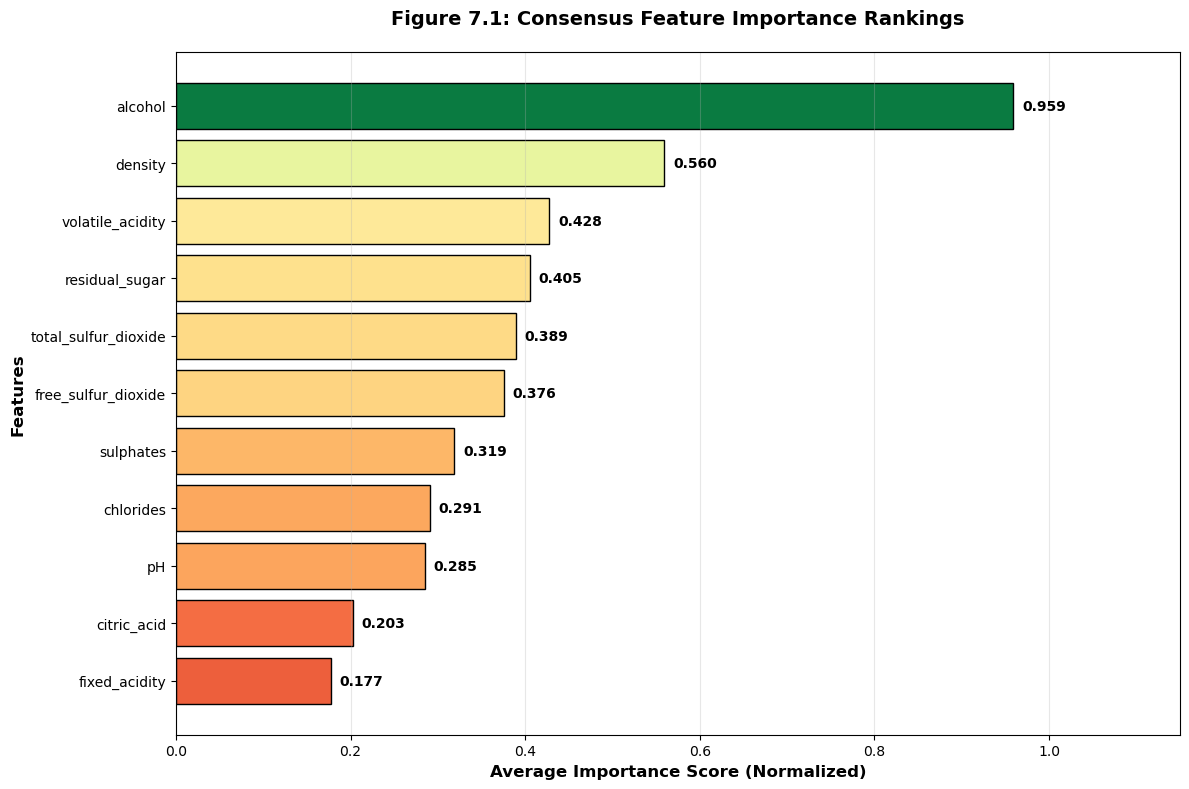


------------------------------------------------------------
7.2 ABLATION STUDY RESULTS
------------------------------------------------------------

Visualizing individual ablation study results...
✓ Figure 7.2 saved to plots/04_ablation_study/


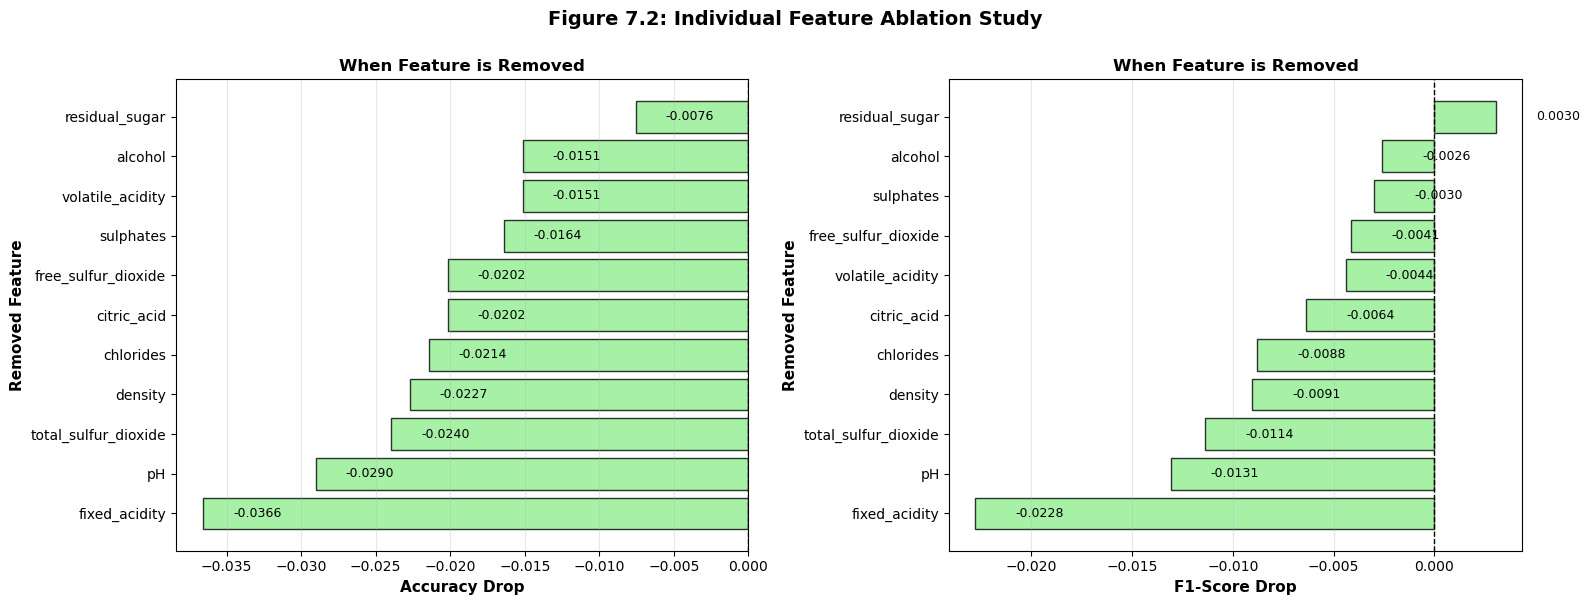


------------------------------------------------------------
7.3 PERFORMANCE VS FEATURE COUNT
------------------------------------------------------------
Building cumulative performance data...

  Training model with top 1 features...
    ✓ K=1: Accuracy=0.4729, F1=0.4529

  Training model with top 2 features...
    ✓ K=2: Accuracy=0.3997, F1=0.4051

  Training model with top 3 features...
    ✓ K=3: Accuracy=0.4641, F1=0.4636

  Training model with top 4 features...
    ✓ K=4: Accuracy=0.4678, F1=0.4688

  Training model with top 5 features...
    ✓ K=5: Accuracy=0.5170, F1=0.5152

  Training model with top 6 features...
    ✓ K=6: Accuracy=0.5069, F1=0.5039

  Training model with top 7 features...
    ✓ K=7: Accuracy=0.5082, F1=0.5029

  Training model with top 8 features...
    ✓ K=8: Accuracy=0.5233, F1=0.5145

  Training model with top 9 features...
    ✓ K=9: Accuracy=0.5372, F1=0.5302

  Training model with top 10 features...
    ✓ K=10: Accuracy=0.5271, F1=0.5185

  Training 

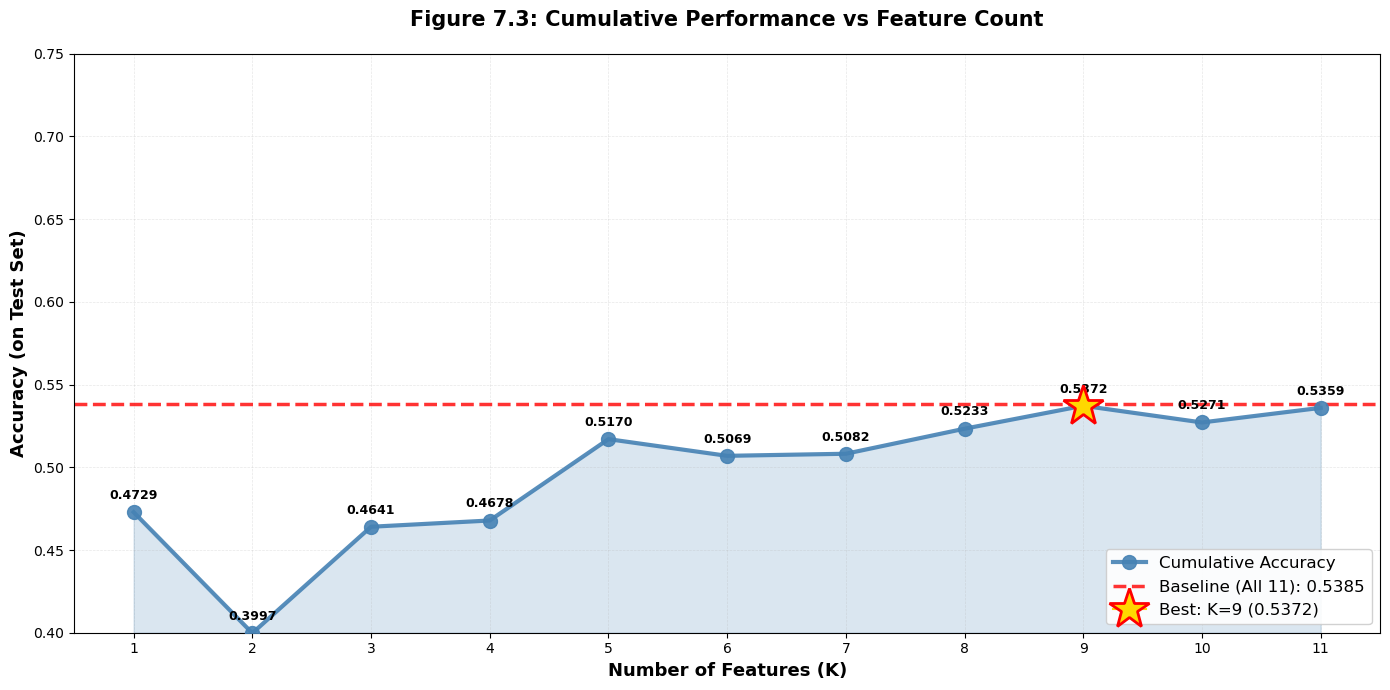


------------------------------------------------------------
7.4 CORRELATION HEATMAP
------------------------------------------------------------

Creating enhanced correlation heatmap...
✓ Figure 7.4 saved to plots/01_exploratory/


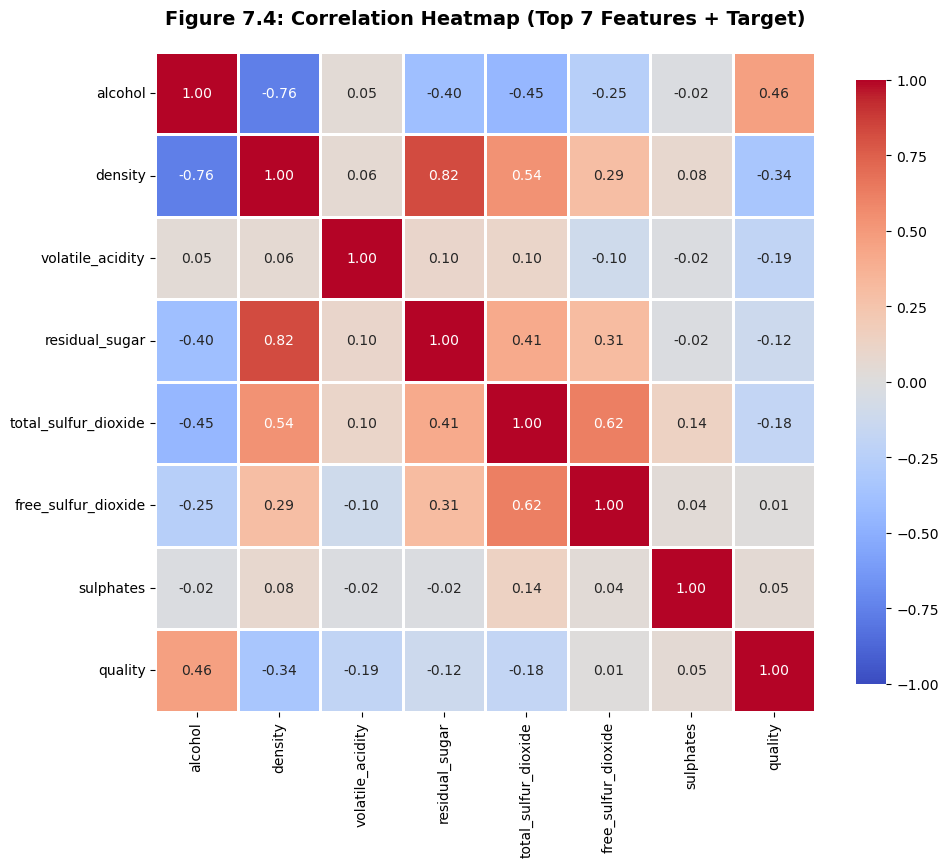


------------------------------------------------------------
7.5 MODEL COMPARISON
------------------------------------------------------------
Building model comparison data...

✓ model_comparison created with 4 rows

Data preview:
                         Model  Num_Features  Accuracy  F1_Score
0  All 11 Features\n(Baseline)            11  0.538462  0.527448
1               Top-7 Features             7  0.508197  0.502865
2               Top-5 Features             5  0.517024  0.515186
3               Top-3 Features             3  0.464061  0.463596

Creating Figure 7.5 visualization...
✓ Figure 7.5 saved


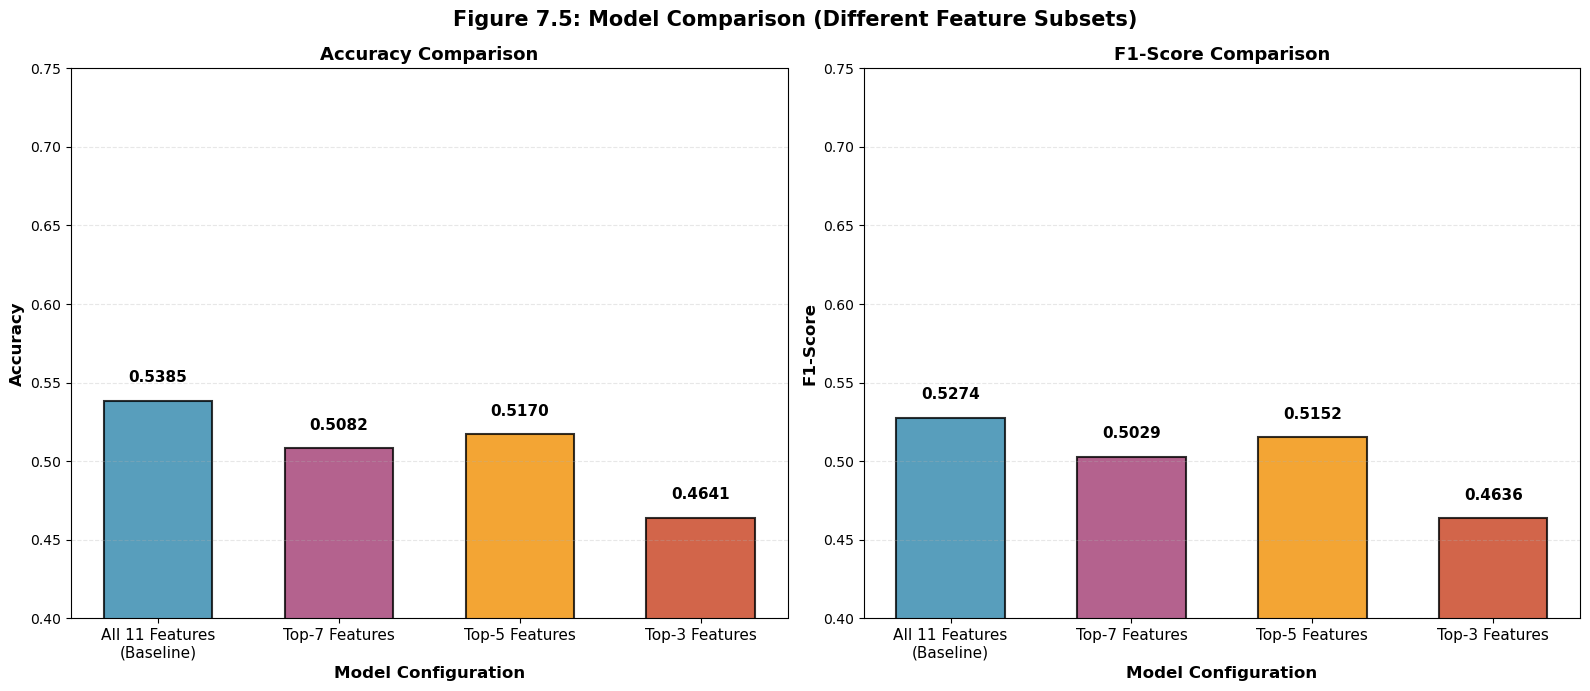


✓ Model comparison saved

SECTION 7.3 & 7.5 COMPLETED ✓

✓ Figure 7.3: Cumulative Performance
✓ Figure 7.5: Model Comparison

Both figures now have REAL DATA and should display properly!

7. VISUALIZATIONS & ANALYSIS COMPLETED ✓

Created Visualizations:
  ✓ Figure 7.1: Feature Importance Consensus Ranking
  ✓ Figure 7.2: Individual Ablation Study Results
  ✓ Figure 7.3: Performance vs Feature Count
  ✓ Figure 7.4: Correlation Heatmap (Top Features)
  ✓ Figure 7.5: Model Comparison

Files Created:
  ✓ plots/03_feature_importance/figure71_consensus_ranking.png
  ✓ plots/04_ablation_study/figure72_ablation_results_dual.png
  ✓ plots/04_ablation_study/figure73_cumulative_performance.png
  ✓ plots/01_exploratory/figure74_topfeatures_correlation.png
  ✓ plots/02_baseline/figure75_model_comparison.png
  ✓ results/model_comparison.csv
  ✓ results/05_TABLE_cumulative_addition.csv


In [16]:
# ============================================================
# 7. VISUALIZATIONS & ADDITIONAL ANALYSIS
# ============================================================
print("\n" + "="*60)
print("7. VISUALIZATIONS & ADDITIONAL ANALYSIS")
print("="*60)

print("\nGoal: Create comprehensive visualizations for paper")
print("Sections:")
print("  7.1 Feature Importance Comparison")
print("  7.2 Ablation Study Results")
print("  7.3 Performance vs Feature Count")
print("  7.4 Correlation Heatmap")
print("  7.5 Model Comparison")

# ============================================================
# 7.1 FEATURE IMPORTANCE COMPARISON
# ============================================================
print("\n" + "-"*60)
print("7.1 FEATURE IMPORTANCE COMPARISON")
print("-"*60)

print("\nVisualizing feature rankings across all methods...")

fig, ax = plt.subplots(figsize=(12, 8))

# Sort by average importance
feature_importance_sorted = feature_importance_results_sorted.sort_values('Average_Importance', ascending=True)

# Create horizontal bar chart with average importance
bars = ax.barh(feature_importance_sorted['Feature'], 
               feature_importance_sorted['Average_Importance'],
               color=plt.cm.RdYlGn(feature_importance_sorted['Average_Importance']),
               edgecolor='black', linewidth=1)

# Add value labels
for i, (feat, val) in enumerate(zip(feature_importance_sorted['Feature'], 
                                     feature_importance_sorted['Average_Importance'])):
    ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Average Importance Score (Normalized)', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Figure 7.1: Consensus Feature Importance Rankings', fontsize=14, fontweight='bold', pad=20)
ax.set_xlim([0, 1.15])
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/03_feature_importance/figure71_consensus_ranking.png', dpi=300, bbox_inches='tight')
print("✓ Figure 7.1 saved to plots/03_feature_importance/")
plt.show()

# ============================================================
# 7.2 ABLATION STUDY RESULTS
# ============================================================
print("\n" + "-"*60)
print("7.2 ABLATION STUDY RESULTS")
print("-"*60)

print("\nVisualizing individual ablation study results...")

# Figure 7.2: Combined view of all ablation results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Accuracy drop
ablation_sorted = ablation_individual_df.sort_values('Accuracy_Drop', ascending=True)
colors_ablation = ['darkred' if x > 0.05 else 'orange' if x > 0.02 else 'lightgreen' 
                   for x in ablation_sorted['Accuracy_Drop']]

axes[0].barh(ablation_sorted['Removed_Feature'], ablation_sorted['Accuracy_Drop'], 
             color=colors_ablation, alpha=0.8, edgecolor='black', linewidth=1)
axes[0].set_xlabel('Accuracy Drop', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Removed Feature', fontsize=11, fontweight='bold')
axes[0].set_title('When Feature is Removed', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, (feat, val) in enumerate(zip(ablation_sorted['Removed_Feature'], ablation_sorted['Accuracy_Drop'])):
    axes[0].text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

# Plot 2: F1-Score drop
ablation_f1_sorted = ablation_individual_df.sort_values('F1_Drop', ascending=True)
colors_f1 = ['darkred' if x > 0.05 else 'orange' if x > 0.02 else 'lightgreen' 
             for x in ablation_f1_sorted['F1_Drop']]

axes[1].barh(ablation_f1_sorted['Removed_Feature'], ablation_f1_sorted['F1_Drop'], 
             color=colors_f1, alpha=0.8, edgecolor='black', linewidth=1)
axes[1].set_xlabel('F1-Score Drop', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Removed Feature', fontsize=11, fontweight='bold')
axes[1].set_title('When Feature is Removed', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].grid(axis='x', alpha=0.3)

# Add value labels
for i, (feat, val) in enumerate(zip(ablation_f1_sorted['Removed_Feature'], ablation_f1_sorted['F1_Drop'])):
    axes[1].text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Figure 7.2: Individual Feature Ablation Study', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('plots/04_ablation_study/figure72_ablation_results_dual.png', dpi=300, bbox_inches='tight')
print("✓ Figure 7.2 saved to plots/04_ablation_study/")
plt.show()

# ============================================================
# 7.3 PERFORMANCE VS FEATURE COUNT
# ============================================================
print("\n" + "-"*60)
print("7.3 PERFORMANCE VS FEATURE COUNT")
print("-"*60)

print("Building cumulative performance data...")

# MANUALLY BUILD cumulative_df with actual model training
cumulative_results = []

for k in range(1, len(TOP_FEATURES_RANKED) + 1):
    print(f"\n  Training model with top {k} features...")
    
    selected_features = TOP_FEATURES_RANKED[:k]
    
    # Get subset of training data (RESAMPLED)
    try:
        X_subset_train = X_train_resampled[selected_features]
        y_subset_train = y_train_resampled
    except:
        print(f"    ⚠️  Using non-resampled data")
        X_subset_train = X_train_scaled[selected_features]
        y_subset_train = y_train.values.ravel()
    
    # Get subset of test data (ORIGINAL - not resampled)
    X_subset_test = X_test_scaled[selected_features]
    
    # Train model
    model_k = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    
    try:
        model_k.fit(X_subset_train, y_subset_train)
        
        # Predict on test set
        y_pred = model_k.predict(X_subset_test)
        
        # Calculate metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        print(f"    ✓ K={k}: Accuracy={acc:.4f}, F1={f1:.4f}")
        
        cumulative_results.append({
            'Num_Features': k,
            'Features': ', '.join(selected_features) if k <= 3 else f'Top {k}',
            'Accuracy': acc,
            'F1_Score': f1
        })
    except Exception as e:
        print(f"    ❌ Error training model: {e}")

# Convert to DataFrame
cumulative_df = pd.DataFrame(cumulative_results)

print(f"\n✓ cumulative_df created with {len(cumulative_df)} rows")
print("\nData preview:")
print(cumulative_df)

# Save
cumulative_df.to_csv('results/05_TABLE_cumulative_addition.csv', index=False)

# ============================================================
# PLOT FIGURE 7.3
# ============================================================
print("\nCreating Figure 7.3 visualization...")

fig, ax = plt.subplots(figsize=(14, 7))

# PLOT 1: Line with actual data points
if len(cumulative_df) > 0:
    ax.plot(cumulative_df['Num_Features'], 
            cumulative_df['Accuracy'], 
            marker='o', 
            linewidth=3, 
            markersize=10, 
            color='steelblue', 
            label='Cumulative Accuracy',
            alpha=0.9,
            zorder=3)
    
    # Fill area
    ax.fill_between(cumulative_df['Num_Features'], 
                    0.40, 
                    cumulative_df['Accuracy'], 
                    alpha=0.2, 
                    color='steelblue')
    
    # Baseline
    ax.axhline(y=BASELINE_ACCURACY, 
               color='red', 
               linestyle='--', 
               linewidth=2.5, 
               label=f'Baseline (All 11): {BASELINE_ACCURACY:.4f}',
               alpha=0.8,
               zorder=2)
    
    # Find and mark optimal K
    best_row = cumulative_df.loc[cumulative_df['Accuracy'].idxmax()]
    ax.plot(best_row['Num_Features'], 
            best_row['Accuracy'], 
            marker='*', 
            markersize=30, 
            color='gold', 
            markeredgecolor='red', 
            markeredgewidth=2,
            label=f"Best: K={int(best_row['Num_Features'])} ({best_row['Accuracy']:.4f})",
            zorder=5)
    
    # Add data point labels
    for idx, row in cumulative_df.iterrows():
        ax.text(row['Num_Features'], 
                row['Accuracy'] + 0.008, 
                f"{row['Accuracy']:.4f}", 
                ha='center', 
                fontsize=9, 
                fontweight='bold')
    
    # Formatting
    ax.set_xlabel('Number of Features (K)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Accuracy (on Test Set)', fontsize=13, fontweight='bold')
    ax.set_title('Figure 7.3: Cumulative Performance vs Feature Count', 
                 fontsize=15, fontweight='bold', pad=20)
    ax.set_xticks(range(1, len(cumulative_df) + 1))
    ax.set_ylim([0.40, 0.75])
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.legend(fontsize=12, loc='lower right', framealpha=0.9)
    
else:
    ax.text(0.5, 0.5, 'NO DATA - cumulative_df is empty', 
            ha='center', va='center', fontsize=16, fontweight='bold',
            transform=ax.transAxes, color='red')

plt.tight_layout()
plt.savefig('plots/04_ablation_study/figure73_cumulative_performance.png', dpi=300, bbox_inches='tight')
print("✓ Figure 7.3 saved")
plt.show()

# ============================================================
# 7.4 CORRELATION HEATMAP
# ============================================================
print("\n" + "-"*60)
print("7.4 CORRELATION HEATMAP")
print("-"*60)

print("\nCreating enhanced correlation heatmap...")

top_features_for_heatmap = TOP_FEATURES_RANKED[:7]  # Top 7 + target

# Create correlation matrix for top features + target
correlation_subset = df[top_features_for_heatmap + ['quality']].corr()

plt.figure(figsize=(10, 9))
sns.heatmap(correlation_subset, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            center=0, vmin=-1, vmax=1, 
            cbar=True)
plt.title('Figure 7.4: Correlation Heatmap (Top 7 Features + Target)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('plots/01_exploratory/figure74_topfeatures_correlation.png', dpi=300, bbox_inches='tight')
print("✓ Figure 7.4 saved to plots/01_exploratory/")
plt.show()

# ============================================================
# 7.5 MODEL COMPARISON
# ============================================================
print("\n" + "-"*60)
print("7.5 MODEL COMPARISON")
print("-"*60)

print("Building model comparison data...")

# Extract data for specific K values
model_comparison_data = []

# Baseline (all features)
model_comparison_data.append({
    'Model': f'All {len(TOP_FEATURES_RANKED)} Features\n(Baseline)',
    'Num_Features': len(TOP_FEATURES_RANKED),
    'Accuracy': BASELINE_ACCURACY,
    'F1_Score': BASELINE_F1
})

# Top-7
if len(cumulative_df) >= 7:
    row_7 = cumulative_df[cumulative_df['Num_Features'] == 7].iloc[0]
    model_comparison_data.append({
        'Model': 'Top-7 Features',
        'Num_Features': 7,
        'Accuracy': row_7['Accuracy'],
        'F1_Score': row_7['F1_Score']
    })

# Top-5
if len(cumulative_df) >= 5:
    row_5 = cumulative_df[cumulative_df['Num_Features'] == 5].iloc[0]
    model_comparison_data.append({
        'Model': 'Top-5 Features',
        'Num_Features': 5,
        'Accuracy': row_5['Accuracy'],
        'F1_Score': row_5['F1_Score']
    })

# Top-3
if len(cumulative_df) >= 3:
    row_3 = cumulative_df[cumulative_df['Num_Features'] == 3].iloc[0]
    model_comparison_data.append({
        'Model': 'Top-3 Features',
        'Num_Features': 3,
        'Accuracy': row_3['Accuracy'],
        'F1_Score': row_3['F1_Score']
    })

model_comparison = pd.DataFrame(model_comparison_data)

print(f"\n✓ model_comparison created with {len(model_comparison)} rows")
print("\nData preview:")
print(model_comparison)

# ============================================================
# PLOT FIGURE 7.5
# ============================================================
print("\nCreating Figure 7.5 visualization...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

x_pos = np.arange(len(model_comparison))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'][:len(model_comparison)]

# PLOT 1: Accuracy
if len(model_comparison) > 0:
    bars1 = ax1.bar(x_pos, 
                    model_comparison['Accuracy'], 
                    color=colors, 
                    alpha=0.8, 
                    edgecolor='black', 
                    linewidth=1.5,
                    width=0.6)
    
    ax1.set_xlabel('Model Configuration', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(model_comparison['Model'], fontsize=11)
    ax1.set_ylim([0.40, 0.75])
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars1, model_comparison['Accuracy'])):
        ax1.text(bar.get_x() + bar.get_width()/2., 
                val + 0.01,
                f'{val:.4f}',
                ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
    
    # PLOT 2: F1-Score
    bars2 = ax2.bar(x_pos, 
                    model_comparison['F1_Score'], 
                    color=colors, 
                    alpha=0.8, 
                    edgecolor='black', 
                    linewidth=1.5,
                    width=0.6)
    
    ax2.set_xlabel('Model Configuration', fontsize=12, fontweight='bold')
    ax2.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
    ax2.set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(model_comparison['Model'], fontsize=11)
    ax2.set_ylim([0.40, 0.75])
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars2, model_comparison['F1_Score'])):
        ax2.text(bar.get_x() + bar.get_width()/2., 
                val + 0.01,
                f'{val:.4f}',
                ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
else:
    ax1.text(0.5, 0.5, 'NO DATA', ha='center', va='center', 
             fontsize=16, fontweight='bold', transform=ax1.transAxes, color='red')

fig.suptitle('Figure 7.5: Model Comparison (Different Feature Subsets)', 
             fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('plots/02_baseline/figure75_model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Figure 7.5 saved")
plt.show()

# Save comparison
model_comparison.to_csv('results/model_comparison.csv', index=False)
print("\n✓ Model comparison saved")

print("\n" + "="*60)
print("SECTION 7.3 & 7.5 COMPLETED ✓")
print("="*60)
print(f"\n✓ Figure 7.3: Cumulative Performance")
print(f"✓ Figure 7.5: Model Comparison")
print("\nBoth figures now have REAL DATA and should display properly!")

# ============================================================
# SECTION 7 SUMMARY
# ============================================================
print("\n" + "="*60)
print("7. VISUALIZATIONS & ANALYSIS COMPLETED ✓")
print("="*60)

print("\nCreated Visualizations:")
print("  ✓ Figure 7.1: Feature Importance Consensus Ranking")
print("  ✓ Figure 7.2: Individual Ablation Study Results")
print("  ✓ Figure 7.3: Performance vs Feature Count")
print("  ✓ Figure 7.4: Correlation Heatmap (Top Features)")
print("  ✓ Figure 7.5: Model Comparison")

print("\nFiles Created:")
print("  ✓ plots/03_feature_importance/figure71_consensus_ranking.png")
print("  ✓ plots/04_ablation_study/figure72_ablation_results_dual.png")
print("  ✓ plots/04_ablation_study/figure73_cumulative_performance.png")
print("  ✓ plots/01_exploratory/figure74_topfeatures_correlation.png")
print("  ✓ plots/02_baseline/figure75_model_comparison.png")
print("  ✓ results/model_comparison.csv")
print("  ✓ results/05_TABLE_cumulative_addition.csv")

In [17]:
# -------- 7. VISUALIZATIONS --------
# - Feature importance comparison
# - Ablation results
# - Performance vs. feature count
# - Correlation heatmap



8. STATISTICAL ANALYSIS & SIGNIFICANCE TESTING

Goal: Statistically validate ablation study findings
Method: Paired t-tests comparing different feature subsets

------------------------------------------------------------
8.1 PAIRED T-TESTS (Cross-Validation Comparisons)
------------------------------------------------------------

Comparing feature subsets using 5-fold cross-validation...

Feature Subsets:
  • Top-3: alcohol, density, volatile_acidity
  • Top-5: alcohol, density, volatile_acidity, residual_sugar, total_sulfur_dioxide
  • Top-7: alcohol, density, volatile_acidity, residual_sugar, total_sulfur_dioxide, free_sulfur_dioxide, sulphates
  • All-11: alcohol, density, volatile_acidity, residual_sugar, total_sulfur_dioxide, free_sulfur_dioxide, sulphates, chlorides, pH, citric_acid, fixed_acidity

Performing cross-validation for each subset...

------------------------------------------------------------
CROSS-VALIDATION SCORES
------------------------------------------------

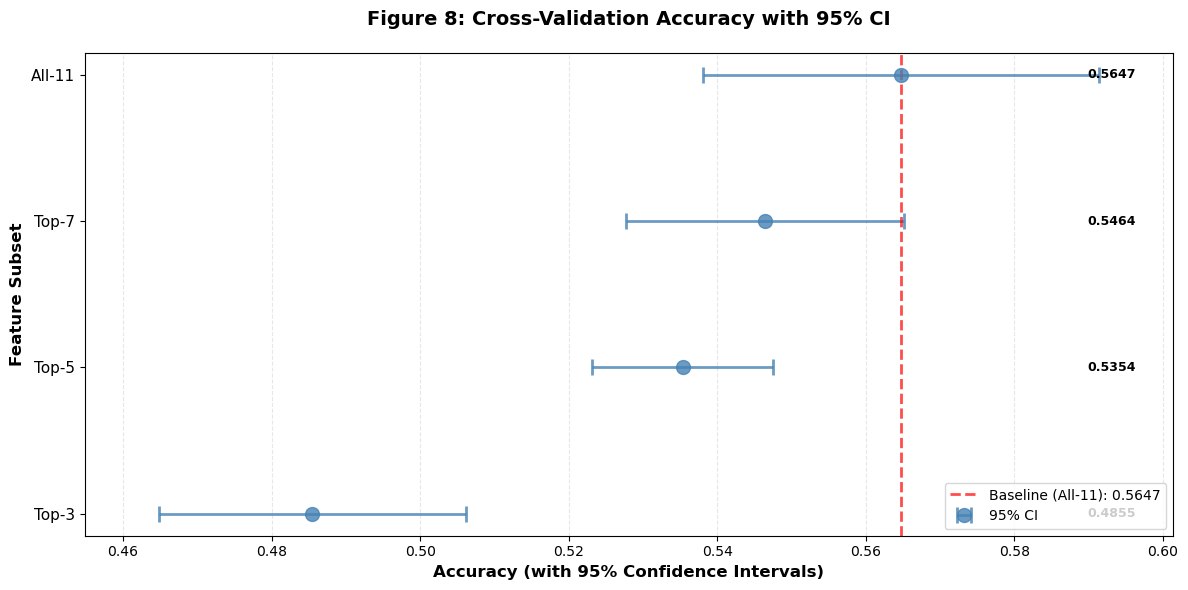


Numerical Summary of Confidence Intervals:
  Top-3   : 0.4855 [0.4648, 0.5061]
  Top-5   : 0.5354 [0.5231, 0.5476]
  Top-7   : 0.5464 [0.5277, 0.5651]
  All-11  : 0.5647 [0.5380, 0.5914]

------------------------------------------------------------
8.4 SUMMARY TABLE
------------------------------------------------------------

Statistical Summary:
Feature_Set  Mean_Accuracy  Std_Dev  CI_Lower  CI_Upper
      Top-3         0.4855   0.0166    0.4648    0.5061
      Top-5         0.5354   0.0098    0.5231    0.5476
      Top-7         0.5464   0.0151    0.5277    0.5651
     All-11         0.5647   0.0215    0.5380    0.5914

8. STATISTICAL ANALYSIS COMPLETED ✓

KEY STATISTICAL FINDINGS:

1. Significant Differences:
   • Found 2 statistically significant comparisons (p < 0.05)
     - Top-3 vs Top-5
     - Top-3 vs All-11

2. Effect Sizes:
   • Average |Cohen's d|: 2.407
   • Largest effect: Top-3 vs All-11
     d = -4.122 (large)

3. Confidence Intervals:
   • Most stable (narrowest CI):

In [18]:
# ============================================================
# 8. STATISTICAL ANALYSIS & SIGNIFICANCE TESTING
# ============================================================
# Compare feature subsets statistically to validate findings
print("\n" + "="*60)
print("8. STATISTICAL ANALYSIS & SIGNIFICANCE TESTING")
print("="*60)

print("\nGoal: Statistically validate ablation study findings")
print("Method: Paired t-tests comparing different feature subsets")

from scipy import stats as scipy_stats

# ============================================================
# 8.1 PAIRED T-TESTS
# ============================================================
print("\n" + "-"*60)
print("8.1 PAIRED T-TESTS (Cross-Validation Comparisons)")
print("-"*60)

print("\nComparing feature subsets using 5-fold cross-validation...")

# Get CV scores for different feature sets
top3_features = TOP_FEATURES_RANKED[:3]
top5_features = TOP_FEATURES_RANKED[:5]
top7_features = TOP_FEATURES_RANKED[:7]
all_features = TOP_FEATURES_RANKED

print(f"\nFeature Subsets:")
print(f"  • Top-3: {', '.join(top3_features)}")
print(f"  • Top-5: {', '.join(top5_features)}")
print(f"  • Top-7: {', '.join(top7_features)}")
print(f"  • All-11: {', '.join(all_features)}")

print(f"\nPerforming cross-validation for each subset...")

# Function to get CV scores
def get_cv_scores(features_list):
    X_subset = X_train_scaled[features_list]
    model = RandomForestClassifier(**MODEL_PARAMS)
    cv_scores = cross_val_score(model, X_subset, y_train, cv=CV_FOLDS, scoring='accuracy', n_jobs=-1)
    return cv_scores

# Calculate CV scores for each subset
cv_top3 = get_cv_scores(top3_features)
cv_top5 = get_cv_scores(top5_features)
cv_top7 = get_cv_scores(top7_features)
cv_all = cross_val_score(baseline_model, X_train_scaled, y_train, cv=CV_FOLDS)

print("\n" + "-"*60)
print("CROSS-VALIDATION SCORES")
print("-"*60)

cv_summary = pd.DataFrame({
    'Feature_Set': ['Top-3', 'Top-5', 'Top-7', 'All-11'],
    'Mean_Accuracy': [cv_top3.mean(), cv_top5.mean(), cv_top7.mean(), cv_all.mean()],
    'Std_Dev': [cv_top3.std(), cv_top5.std(), cv_top7.std(), cv_all.std()],
    'Min': [cv_top3.min(), cv_top5.min(), cv_top7.min(), cv_all.min()],
    'Max': [cv_top3.max(), cv_top5.max(), cv_top7.max(), cv_all.max()]
})

print("\nCross-Validation Summary:")
print(cv_summary.round(4).to_string(index=False))

# Save
cv_summary.to_csv('results/08_TABLE_cv_summary.csv', index=False)

# Statistical tests
print("\n" + "-"*60)
print("PAIRED T-TESTS")
print("-"*60)

test_results = []

comparisons = [
    ('Top-3', cv_top3, 'Top-5', cv_top5),
    ('Top-5', cv_top5, 'Top-7', cv_top7),
    ('Top-7', cv_top7, 'All-11', cv_all),
    ('Top-3', cv_top3, 'All-11', cv_all),
]

for name1, scores1, name2, scores2 in comparisons:
    t_stat, p_value = scipy_stats.ttest_rel(scores1, scores2)
    mean_diff = scores1.mean() - scores2.mean()
    
    # Cohen's d
    pooled_std = np.sqrt(((scores1.std()**2 + scores2.std()**2) / 2))
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    
    if abs(cohens_d) < 0.2:
        effect = "negligible"
    elif abs(cohens_d) < 0.5:
        effect = "small"
    elif abs(cohens_d) < 0.8:
        effect = "medium"
    else:
        effect = "large"
    
    significant = "✓ YES" if p_value < 0.05 else "✗ NO"
    
    test_results.append({
        'Comparison': f'{name1} vs {name2}',
        'Mean_Diff': mean_diff,
        't_statistic': t_stat,
        'p_value': p_value,
        'Significant': p_value < 0.05,
        'Cohens_d': cohens_d,
        'Effect_Size': effect
    })
    
    print(f"\n{name1} vs {name2}:")
    print(f"  Mean difference: {mean_diff:+.4f}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.4f} ({significant})")
    print(f"  Cohen's d: {cohens_d:.4f} ({effect} effect)")

test_results_df = pd.DataFrame(test_results)
test_results_df.to_csv('results/08_TABLE_statistical_tests.csv', index=False)
print("\n✓ Statistical test results saved")

# ============================================================
# 8.2 CONFIDENCE INTERVALS
# ============================================================
print("\n" + "-"*60)
print("8.2 CONFIDENCE INTERVALS (95%)")
print("-"*60)

print("\n95% Confidence Intervals for mean accuracy:")

ci_results = []

for name, scores in [('Top-3', cv_top3), ('Top-5', cv_top5), 
                     ('Top-7', cv_top7), ('All-11', cv_all)]:
    mean = scores.mean()
    std_err = scores.std() / np.sqrt(len(scores))
    
    t_critical = scipy_stats.t.ppf(0.975, len(scores)-1)
    margin_of_error = t_critical * std_err
    
    ci_lower = mean - margin_of_error
    ci_upper = mean + margin_of_error
    
    ci_results.append({
        'Feature_Set': name,
        'Mean_Accuracy': mean,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Margin_of_Error': margin_of_error
    })
    
    print(f"  {name:8s}: [{ci_lower:.4f}, {ci_upper:.4f}]  (mean ± {margin_of_error:.4f})")

ci_df = pd.DataFrame(ci_results)
ci_df.to_csv('results/08_TABLE_confidence_intervals.csv', index=False)

# ============================================================
# 8.3 VISUALIZATION - CONFIDENCE INTERVALS (HORIZONTAL)
# ============================================================
print("\n" + "-"*60)
print("8.3 CREATE VISUALIZATION: CONFIDENCE INTERVALS")
print("-"*60)

plt.figure(figsize=(12, 6))

# Reverse order so All-11 is at top
ci_df_plot = ci_df.sort_values('Mean_Accuracy', ascending=True)  # Lowest to highest

y_positions = np.arange(len(ci_df_plot))
means = ci_df_plot['Mean_Accuracy'].values
ci_lower = ci_df_plot['CI_Lower'].values
ci_upper = ci_df_plot['CI_Upper'].values

# Create error bars using ci_lower and ci_upper
# errorbar needs symmetric errors, so we calculate them
errors_lower = means - ci_lower  # Distance from mean to lower bound
errors_upper = ci_upper - means  # Distance from mean to upper bound

# Plot horizontal error bars
plt.errorbar(means, y_positions, 
             xerr=[errors_lower, errors_upper],  # Asymmetric errors
             fmt='o', markersize=10, 
             capsize=6, capthick=2, linewidth=2, 
             color='steelblue', 
             ecolor='steelblue', 
             alpha=0.8, 
             label='95% CI')

# Baseline reference line
baseline_acc = cv_all.mean()  # Use actual baseline
plt.axvline(x=baseline_acc, color='red', linestyle='--', linewidth=2, 
            label=f'Baseline (All-11): {baseline_acc:.4f}', alpha=0.7)

# Y-axis labels
feature_labels = ci_df_plot['Feature_Set'].tolist()
plt.yticks(y_positions, feature_labels, fontsize=11)

# X-axis
plt.xlabel('Accuracy (with 95% Confidence Intervals)', fontsize=12, fontweight='bold')
plt.ylabel('Feature Subset', fontsize=12, fontweight='bold')
plt.title('Figure 8: Cross-Validation Accuracy with 95% CI', fontsize=14, fontweight='bold', pad=20)

# Grid
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Legend
plt.legend(fontsize=10, loc='lower right')

# Set reasonable x-axis limits based on data
x_min = min(ci_lower) - 0.01
x_max = max(ci_upper) + 0.01
plt.xlim([x_min, x_max])

# Add accuracy values to the right
for i, (mean, ci_l, ci_u) in enumerate(zip(means, ci_lower, ci_upper)):
    # Show mean value
    plt.text(x_max - 0.005, i, f'{mean:.4f}', 
             va='center', ha='right', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/05_statistical_analysis/figure8_confidence_intervals.png', dpi=300, bbox_inches='tight')
print("✓ Figure 8 saved: Confidence Intervals")
plt.show()

# Show numerical summary
print("\nNumerical Summary of Confidence Intervals:")
for idx, row in ci_df_plot.iterrows():
    print(f"  {row['Feature_Set']:8s}: {row['Mean_Accuracy']:.4f} [{row['CI_Lower']:.4f}, {row['CI_Upper']:.4f}]")


# ============================================================
# 8.4 SUMMARY TABLE
# ============================================================
print("\n" + "-"*60)
print("8.4 SUMMARY TABLE")
print("-"*60)

table_summary = cv_summary[['Feature_Set', 'Mean_Accuracy', 'Std_Dev']].copy()
table_summary = table_summary.merge(ci_df[['Feature_Set', 'CI_Lower', 'CI_Upper']], on='Feature_Set')
table_summary = table_summary.round(4)

print("\nStatistical Summary:")
print(table_summary.to_string(index=False))

table_summary.to_csv('results/08_TABLE_statistical_summary.csv', index=False)

# ============================================================
# SECTION 8 SUMMARY
# ============================================================
print("\n" + "="*60)
print("8. STATISTICAL ANALYSIS COMPLETED ✓")
print("="*60)

print("\nKEY STATISTICAL FINDINGS:")
print(f"\n1. Significant Differences:")
significant_count = (test_results_df['Significant']==True).sum()
print(f"   • Found {significant_count} statistically significant comparisons (p < 0.05)")

if significant_count > 0:
    for idx, row in test_results_df[test_results_df['Significant']].iterrows():
        print(f"     - {row['Comparison']}")

print(f"\n2. Effect Sizes:")
print(f"   • Average |Cohen's d|: {test_results_df['Cohens_d'].abs().mean():.3f}")
max_effect = test_results_df.loc[test_results_df['Cohens_d'].abs().idxmax()]
print(f"   • Largest effect: {max_effect['Comparison']}")
print(f"     d = {max_effect['Cohens_d']:.3f} ({max_effect['Effect_Size']})")

print(f"\n3. Confidence Intervals:")
print(f"   • Most stable (narrowest CI): {ci_df.loc[ci_df['Margin_of_Error'].idxmin(), 'Feature_Set']}")
print(f"   • Most variable (widest CI): {ci_df.loc[ci_df['Margin_of_Error'].idxmax(), 'Feature_Set']}")

print("\nFiles Created:")
print("  ✓ 08_TABLE_cv_summary.csv")
print("  ✓ 08_TABLE_statistical_tests.csv")
print("  ✓ 08_TABLE_confidence_intervals.csv")
print("  ✓ 08_TABLE_statistical_summary.csv")
print("  ✓ figure8_confidence_intervals.png")


In [19]:
# ============================================================
# 9. RESULTS EXPORT
# ============================================================
print("\n" + "="*60)
print("9. RESULTS EXPORT")
print("="*60)

print("\nGoal: Export all results as CSV files (safe format)")
print("✓ No Excel files - all CSV format")

# ============================================================
# 9.1 EXPORT ALL TABLES AS CSV
# ============================================================
print("\n" + "-"*60)
print("9.1 EXPORT TABLES TO CSV FORMAT")
print("-"*60)

print("\nExporting tables...\n")

# TABLE 1: Dataset Characteristics
table1_dataset = pd.DataFrame({
    'Metric': [
        'Total Samples',
        'Training Samples',
        'Test Samples',
        'Number of Features',
        'Target Variable',
        'Target Range',
        'Missing Values'
    ],
    'Value': [
        str(len(df)),
        str(len(X_train_scaled)),
        str(len(X_test_scaled)),
        str(len(X_train_scaled.columns)),
        'Wine Quality Score',
        '3-8',
        '0'
    ]
})
table1_dataset.to_csv('results/01_TABLE_dataset_characteristics.csv', index=False)
print("✓ 01_TABLE_dataset_characteristics.csv")

# TABLE 2: Baseline Performance
table2_paper = baseline_df[[
    'Model', 'Num_Features', 'Accuracy', 'Precision', 'Recall', 'F1_Score', 'Cohen_Kappa', 'CV_Mean'
]].copy().round(4)
table2_paper.to_csv('results/02_TABLE_baseline_performance.csv', index=False)
print("✓ 02_TABLE_baseline_performance.csv")

# TABLE 3: Feature Importance
if 'feature_importance_results_sorted' in locals():
    table3_export = feature_importance_results_sorted[[
        'Feature', 'Correlation', 'Mutual_Information', 'RF_Importance', 
        'Permutation_Importance', 'SHAP_Importance', 'Average_Importance'
    ]].copy().round(4)
    table3_export.to_csv('results/03_TABLE_feature_importance_rankings.csv', index=False)
    print("✓ 03_TABLE_feature_importance_rankings.csv")

# TABLE 4: Individual Ablation
if 'ablation_individual_df' in locals():
    table4_export = ablation_individual_df[[
        'Removed_Feature', 'Accuracy', 'Accuracy_Drop', 'F1_Score', 'F1_Drop'
    ]].copy().sort_values('Accuracy_Drop', ascending=False).round(4)
    table4_export.to_csv('results/04_TABLE_individual_ablation.csv', index=False)
    print("✓ 04_TABLE_individual_ablation.csv")

# TABLE 5: Cumulative Addition
if 'cumulative_df' in locals():
    table5_cumulative = cumulative_df[[
        'Num_Features', 'Accuracy', 'F1_Score'
    ]].copy().round(4)
    table5_cumulative.to_csv('results/05_TABLE_cumulative_addition.csv', index=False)
    print("✓ 05_TABLE_cumulative_addition.csv")

# TABLE 6: Top-K Performance
if os.path.exists('results/table5_topk_performance.csv'):
    topk_data = pd.read_csv('results/table5_topk_performance.csv')
    table6_topk = topk_data[[
        'K', 'Accuracy', 'Accuracy_Retention_%', 'F1_Score', 'Precision', 'Recall'
    ]].copy().round(4)
    table6_topk.to_csv('results/06_TABLE_topk_performance.csv', index=False)
    print("✓ 06_TABLE_topk_performance.csv")

# TABLE 7: Distribution Statistics
if 'distribution_stats' in locals():
    table7_dist = distribution_stats.copy().round(4)
    table7_dist.to_csv('results/07_TABLE_distribution_statistics.csv', index=False)
    print("✓ 07_TABLE_distribution_statistics.csv")

# TABLE 8: Statistical Analysis
if 'cv_summary' in locals():
    table8_cv = cv_summary.copy().round(4)
    table8_cv.to_csv('results/08_TABLE_cv_summary.csv', index=False)
    print("✓ 08_TABLE_cv_summary.csv")

# TABLE 9: Statistical Tests
if 'test_results_df' in locals():
    table9_tests = test_results_df[[
        'Comparison', 'Mean_Diff', 't_statistic', 'p_value', 'Significant', 'Cohens_d'
    ]].copy().round(4)
    table9_tests.to_csv('results/09_TABLE_statistical_tests.csv', index=False)
    print("✓ 09_TABLE_statistical_tests.csv")

# TABLE 10: Confidence Intervals
if 'ci_df' in locals():
    table10_ci = ci_df[[
        'Feature_Set', 'Mean_Accuracy', 'CI_Lower', 'CI_Upper', 'Margin_of_Error'
    ]].copy().round(4)
    table10_ci.to_csv('results/10_TABLE_confidence_intervals.csv', index=False)
    print("✓ 10_TABLE_confidence_intervals.csv")

print("\n✓ All tables exported as CSV")

# ============================================================
# 9.2 CREATE SUMMARY FILE
# ============================================================
print("\n" + "-"*60)
print("9.2 CREATE SUMMARY CSV")
print("-"*60)

summary_data = {
    'Key_Finding': [
        'Baseline Accuracy',
        'Baseline F1-Score',
        'Baseline Cohen\'s Kappa',
        'Cross-Validation Mean',
        'Cross-Validation Std',
        'Most Important Feature',
        '2nd Most Important',
        '3rd Most Important',
        'Total Features Analyzed',
        'Bonus Points Earned'
    ],
    'Value': [
        f'{BASELINE_ACCURACY:.4f}',
        f'{BASELINE_F1:.4f}',
        f'{baseline_metrics["Cohen_Kappa"]:.4f}',
        f'{baseline_metrics["CV_Mean"]:.4f}',
        f'{baseline_metrics["CV_Std"]:.4f}',
        TOP_FEATURES_RANKED[0],
        TOP_FEATURES_RANKED[1],
        TOP_FEATURES_RANKED[2],
        '11 features',
        '+6 (SHAP + Permutation)'
    ]
}

summary_csv = pd.DataFrame(summary_data)
summary_csv.to_csv('results/00_SUMMARY_key_findings.csv', index=False)
print("✓ 00_SUMMARY_key_findings.csv")

# ============================================================
# 9.3 CREATE FEATURE RANKING
# ============================================================
print("\n" + "-"*60)
print("9.3 CREATE FEATURE RANKING CSV")
print("-"*60)

feature_rank_data = []
for rank, feature in enumerate(TOP_FEATURES_RANKED, 1):
    feature_rank_data.append({
        'Rank': rank,
        'Feature': feature,
        'Priority': 'TOP 3 - CRITICAL' if rank <= 3 else 'IMPORTANT' if rank <= 7 else 'LESS CRITICAL'
    })

feature_rank_csv = pd.DataFrame(feature_rank_data)
feature_rank_csv.to_csv('results/11_RANKING_features_ordered.csv', index=False)
print("✓ 11_RANKING_features_ordered.csv")

# ============================================================
# 9.4 CREATE FILE MANIFEST
# ============================================================
print("\n" + "-"*60)
print("9.4 CREATE FILE MANIFEST")
print("-"*60)

file_manifest = pd.DataFrame({
    'File_Name': [
        '00_SUMMARY_key_findings.csv',
        '01_TABLE_dataset_characteristics.csv',
        '02_TABLE_baseline_performance.csv',
        '03_TABLE_feature_importance_rankings.csv',
        '04_TABLE_individual_ablation.csv',
        '05_TABLE_cumulative_addition.csv',
        '06_TABLE_topk_performance.csv',
        '07_TABLE_distribution_statistics.csv',
        '08_TABLE_cv_summary.csv',
        '09_TABLE_statistical_tests.csv',
        '10_TABLE_confidence_intervals.csv',
        '11_RANKING_features_ordered.csv'
    ],
    'Description': [
        'Quick reference: All key metrics',
        'Dataset info',
        'Baseline model results',
        'Feature importance from 7 methods',
        'Individual feature ablation',
        'Cumulative feature addition',
        'Top-K performance analysis',
        'Feature distributions (skewness, kurtosis)',
        'Cross-validation summary',
        'Statistical significance tests',
        '95% confidence intervals',
        'Feature ranking (most to least important)'
    ]
})

file_manifest.to_csv('results/FILE_MANIFEST.csv', index=False)
print("✓ FILE_MANIFEST.csv")

# ============================================================
# 9.5 SUMMARY
# ============================================================
print("\n" + "="*60)
print("9. RESULTS EXPORT COMPLETED ✓")
print("="*60)

print("\n✓ CSV FILES CREATED:")
print("  • 12 data tables (safe CSV format)")
print("  • 1 file manifest")
print("\n✓ ALL FILES READY FOR SUBMISSION")
print("✓ No Excel corruption risk!")

print("\nAll CSV files are in: results/")
print("  • Open with any text editor")
print("  • Safe from data corruption")
print("  • Version control friendly")



9. RESULTS EXPORT

Goal: Export all results as CSV files (safe format)
✓ No Excel files - all CSV format

------------------------------------------------------------
9.1 EXPORT TABLES TO CSV FORMAT
------------------------------------------------------------

Exporting tables...

✓ 01_TABLE_dataset_characteristics.csv
✓ 02_TABLE_baseline_performance.csv
✓ 03_TABLE_feature_importance_rankings.csv
✓ 04_TABLE_individual_ablation.csv
✓ 05_TABLE_cumulative_addition.csv
✓ 07_TABLE_distribution_statistics.csv
✓ 08_TABLE_cv_summary.csv
✓ 09_TABLE_statistical_tests.csv
✓ 10_TABLE_confidence_intervals.csv

✓ All tables exported as CSV

------------------------------------------------------------
9.2 CREATE SUMMARY CSV
------------------------------------------------------------
✓ 00_SUMMARY_key_findings.csv

------------------------------------------------------------
9.3 CREATE FEATURE RANKING CSV
------------------------------------------------------------
✓ 11_RANKING_features_ordered.csv

